# TESS Variable Star Categorization

## A Reproducible Research Notebook on Photometric Provenance and Variable-Star Classification

This notebook is written as a **paper-style research document**. The main text emphasizes scientific motivation, methodology, results, and interpretation. Full implementation code is included for reproducibility, but long code cells are collapsed by default so the notebook remains readable.

The central research question is:

> **How does photometric provenance influence the characterization and classification of variable stars observed by TESS?**


# Chapter 1 – Scientific Motivation and Research Question

## 1.1 Motivation

Variable stars are central objects in observational astrophysics because their brightness variations encode information about stellar interiors, pulsation, binary geometry, rotation, accretion, circumstellar material, and stellar evolution. RR Lyrae stars and Cepheids are especially important because their pulsations are tied to distance-scale work, while eclipsing binaries provide geometric constraints on stellar radii and masses.

The **Transiting Exoplanet Survey Satellite (TESS)** has become a major resource for time-domain stellar astrophysics because it provides high-cadence, space-based photometry across most of the sky. However, TESS light curves are not produced by a single uniform pipeline. In this project, the main photometric provenance categories are:

- **SPOC**: Science Processing Operations Center light curves.
- **QLP**: Quick-Look Pipeline light curves.
- **TESSCut**: light curves extracted from Full-Frame Image cutouts.

These products observe the same underlying sky but differ in extraction, calibration, aperture selection, background treatment, and systematic correction. Therefore, the same star may have different measured amplitude, scatter, morphology, or periodogram structure depending on the photometric product used.

This project treats that difference not as a technical nuisance, but as the central scientific subject.


## 1.2 Primary Research Question

> **How does photometric provenance influence the characterization and classification of variable stars observed by TESS?**

The goal is not simply to maximize Random Forest accuracy. Instead, machine learning is used as a **diagnostic tool** to reveal how different TESS photometric products alter measurable variability signatures.

Supporting questions:

1. How do SPOC, QLP, and TESSCut differ in availability across variable-star families?
2. How do measured period, amplitude, scatter, and morphology features change with provenance?
3. Which variable-star classes are most sensitive to provenance?
4. How does provenance affect Random Forest classification accuracy and feature importance?
5. Can phase-folded morphology explain provenance-dependent classification behavior?
6. Are observed provenance effects likely caused by real photometric-product differences, or could they be explained by VSX-to-TIC cross-match errors?


## 1.3 Research Gap

Prior studies have applied machine learning to classify variable stars using Kepler and TESS light curves. However, the reviewed literature does not appear to systematically quantify how different TESS light-curve products affect downstream variable-star classification, feature importance, and class-specific astrophysical interpretation.

This project therefore focuses on **photometric provenance** as the scientific variable of interest.

A stronger framing of the project is not:

> Random Forest classification of TESS variable stars.

Rather, it is:

> A study of how different TESS photometric products alter the measured variability signatures of astrophysical classes, using machine learning as one diagnostic tool.


# Chapter 2 – Dataset Construction

## 2.1 Overview of the Dataset Pipeline

The dataset-construction pipeline transforms a catalog of known variable stars into a curated multi-provenance TESS light-curve dataset. In this version, the VSX catalog query and the TESS/TIC matching step are intentionally separated so that the VSX sample can be audited before any TESS availability logic is applied.

```text
AAVSO VSX variable-star catalog
        ↓
[2.2 / REQ-1] Pure VSX query class definition
        ↓
[2.3 / REQ-4] VSX→TESS/TIC match class definition
        ↓
[2.4] Pipeline driver class definition and safe reproducibility controls
        ↓
[2.5 / REQ-1, REQ-2] Execute pure VSX query
        ↓
Save VSX sample to VSX_METADATA_FILE
        ↓
[REQ-2] Cache every VSX XML response in VSX_CACHE_FOLDER
        ↓
[2.6] HTTP 405 sky-cell query investigation and temporary subcell fallback patch
        ↓
[2.7] XRAY special handling/test and expanded XRAY XML refresh
        ↓
[2.8] Standalone generation of VSX_METADATA_FILE from cached XML
        ↓
[2.9 / REQ-3] Validation: VSX sample balance checks
        ↓
[2.10 / REQ-4] Execute pure TESS/TIC match step
        ↓
Save TESS-match metadata to VSX_TESS_MATCH_METADATA_FILE
        ↓
Light-curve acquisition: SPOC → QLP → TESSCut
        ↓
Feature extraction, provenance analysis, and model evaluation
```

This separation is important scientifically. The VSX sample defines the astrophysical population being studied, while the TESS match step defines which photometric products are available for those same stars. Keeping the two files separate makes it easier to diagnose whether later class imbalance comes from the VSX query, from TESS product availability, or from downstream quality-control steps.


In [ ]:
# Global execution guard

# Leave these False when reading or rerunning the notebook for documentation.
# Set them to True only when intentionally regenerating specific pipeline products.
RUN_VSX_CATALOG_QUERY = False
RUN_TESS_MATCH = True
RUN_TESS_LIGHT_CURVE_DOWNLOAD = True
RUN_LIGHT_CURVE_STANDARDIZATION = True
RUN_SANITY_CHECKS = True

VSX_CACHE_FOLDER = "/data/projects/TESS-research/data_pipeline/VSXCache"
TESS_CACHE_FOLDER = "/data/projects/TESS-research/data_pipeline/TESSCache"

# Pure VSX output: contains only VSX-derived object records and labels.
VSX_METADATA_FILE = "/data/projects/TESS-research/data_pipeline/VSXCache/VSXMetadata.parquet"

# Pure TESS/TIC match output: contains VSX records enriched with TIC candidates and
# SPOC/QLP availability metadata, but does not download light curves.
VSX_TESS_MATCH_METADATA_FILE = "/data/projects/TESS-research/data_pipeline/TESSCache/VSX_TESS_MATCH_Metadata.parquet"

# Light-curve acquisition output.
AUGMENTED_METADATA_FILE = "/data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet"

RADIUS_ARCSEC = 1.0
MAX_TIC_CANDIDATES = 1
VSX_QUERY_MAX_WORKERS = 8

print("RUN_VSX_CATALOG_QUERY =", RUN_VSX_CATALOG_QUERY)
print("RUN_TESS_MATCH =", RUN_TESS_MATCH)
print("RUN_TESS_LIGHT_CURVE_DOWNLOAD =", RUN_TESS_LIGHT_CURVE_DOWNLOAD)
print("RUN_LIGHT_CURVE_STANDARDIZATION =", RUN_LIGHT_CURVE_STANDARDIZATION)
print("RUN_SANITY_CHECKS =", RUN_SANITY_CHECKS)
print("VSX_METADATA_FILE =", VSX_METADATA_FILE)
print("VSX_TESS_MATCH_METADATA_FILE =", VSX_TESS_MATCH_METADATA_FILE)
print("VSX_QUERY_MAX_WORKERS =", VSX_QUERY_MAX_WORKERS)


RUN_VSX_CATALOG_QUERY = False
RUN_TESS_MATCH = True
RUN_TESS_LIGHT_CURVE_DOWNLOAD = False
RUN_LIGHT_CURVE_STANDARDIZATION = False
RUN_SANITY_CHECKS = False
VSX_METADATA_FILE = /data/projects/TESS-research/data_pipeline/VSXCache/VSXMetadata.parquet
VSX_TESS_MATCH_METADATA_FILE = /data/projects/TESS-research/data_pipeline/TESSCache/VSX_TESS_MATCH_Metadata.parquet
VSX_QUERY_MAX_WORKERS = 8


## 2.2 Pure VSX Query and Label Construction Class Definition `[REQ-1, REQ-2]`

The astrophysical labels in this project come from the **AAVSO International Variable Star Index (VSX)**. VSX provides object names, sky coordinates, periods when available, and detailed variability types.

This section separates the VSX work into two reproducible stages:

1. a parallel VSX XML-cache query that writes raw VSX responses to `VSX_CACHE_FOLDER`;
2. a standalone cached-XML parsing step that builds `VSX_METADATA_FILE`.

It does **not** cross-match to TIC and does **not** inspect TESS light-curve availability.

The raw VSX taxonomy is scientifically rich but too detailed for a first-pass machine-learning dataset, so related subtypes are grouped into broader astrophysical families. For example, `RRAB`, `RRC`, and `RRD` are grouped into **RRLYR**, while `EA`, `EB`, `EW`, and `E` are grouped into **ECLIPSING**.

Every VSX web-service response is cached as an XML/VOTable file under `VSX_CACHE_FOLDER`, and the cached XML files are later used to construct the sampled VSX metadata table. This supports reproducibility and allows later inspection of exactly what the VSX service returned for each subtype/sky-cell query.


### Class Definition: VSX category loading and XML response caching

Python class for querying VSX by normalized family and raw subtype. The `_httpGetVsxContent()` method writes each VSX response to `VSX_CACHE_FOLDER` as a `.xml` file before parsing it.


In [2]:
# VSX category loading logic

import sys
import os
import re
import math
import random
import time
import logging
import xml.etree.ElementTree as ET
from io import BytesIO
from collections import defaultdict

import requests
import numpy as np
import pandas as pd
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from astropy.io.votable import parse_single_table
import lightkurve as lk
import warnings
import hashlib
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

class VSXCategoryLoader:
    def __init__(self, cacheFolder='VSXCache', refreshCache=False, useSkyBalancedQuery=True, nRaBins=8, nDecBins=4, maxWorkers=8):
        """
        VSXCategoryLoader provides a starter curated dictionary that maps raw
        AAVSO VSX variable-star types into broader normalized families that are
        easier to use for TESS analysis and machine-learning pipelines.

        Core design idea
        ----------------
        The raw VSX type system is astrophysically meaningful but can be too
        granular or inconsistent for a first-pass research pipeline. This class
        adds a curated family layer and provides a family-driven loader:

            input  -> {"ECLIPSING": 100, "RRLYR": 50}
            output -> {
                         "ECLIPSING": [starRecord1, starRecord2, ...],
                         "RRLYR": [starRecord3, starRecord4, ...]
                      }

        Important note
        --------------
        loadCategories() is intentionally family-driven. It is designed to
        retrieve a requested number of variable stars for each normalized family
        by querying the AAVSO VSX service directly.
        """
        self.logger = logging.getLogger("VSXCategoryLoader")
        self.cacheFolder = cacheFolder
        if not os.path.exists(self.cacheFolder):
            os.makedirs(self.cacheFolder)
        self.refreshCache = refreshCache

        self.vsxBaseUrl = "https://www.aavso.org/vsx/index.php"
        self.httpTimeoutSec = 600
        self.useSkyBalancedQuery = useSkyBalancedQuery
        self.nRaBins = nRaBins
        self.nDecBins = nDecBins
        self.maxWorkers = maxWorkers
        self._cacheWriteLock = threading.Lock()

        # Keep a reusable session for VSX traffic and automatically recover
        # from transient network/server failures.
        self.httpSession = requests.Session()
        retryPolicy = Retry(
            total=3,
            connect=3,
            read=3,
            status=3,
            backoff_factor=0.5,
            status_forcelist=(429, 500, 502, 503, 504),
            allowed_methods=frozenset(["GET"]),
            raise_on_status=False,
        )
        adapter = HTTPAdapter(max_retries=retryPolicy)
        self.httpSession.mount("https://", adapter)
        self.httpSession.mount("http://", adapter)

        # ------------------------------------------------------------
        # Raw VSX type -> normalized family
        # ------------------------------------------------------------
        self.vsxTypeToFamily = {
            # --------------------------------------------------------
            # ECLIPSING BINARIES
            # --------------------------------------------------------
            # Binary-star systems whose brightness variations are caused by
            # eclipses along our line of sight. These are among the most
            # important classes for TESS because they are strongly periodic,
            # often high signal-to-noise, and can resemble exoplanet transits.
            #
            # EA = Algol-type detached binary
            # EB = Beta Lyrae-type semi-detached binary
            # EW = W UMa-type contact binary
            # E  = generic eclipsing binary
            "EA": "ECLIPSING",
            "EB": "ECLIPSING",
            "EW": "ECLIPSING",
            "E": "ECLIPSING",

            # --------------------------------------------------------
            # ROTATIONAL / ELLIPSOIDAL VARIABLES
            # --------------------------------------------------------
            # Variables driven by rotation, star spots, magnetic structure,
            # or tidal distortion rather than eclipses. These are often
            # periodic or quasi-periodic and can look sinusoidal in light
            # curves, making them important comparison cases for pulsators.
            #
            # ELL = ellipsoidal variable
            # RS  = RS CVn active binary
            # BY  = BY Dra spotted dwarf
            # ACV = Alpha2 CVn magnetic variable
            # ROT = generic rotational variable
            "ELL": "ELLIPSOIDAL_ROT",
            "RS": "ELLIPSOIDAL_ROT",
            "BY": "ELLIPSOIDAL_ROT",
            "ACV": "ELLIPSOIDAL_ROT",
            "ROT": "ELLIPSOIDAL_ROT",

            # --------------------------------------------------------
            # RR LYRAE
            # --------------------------------------------------------
            # Old, low-mass radial pulsators on the horizontal branch.
            # These are classic benchmark stars for period-finding and
            # Galactic-structure work, and they often have clean TESS signals.
            #
            # RRAB = fundamental mode
            # RRC  = first overtone
            # RRD  = double-mode
            # RR   = generic RR Lyrae
            "RR": "RRLYR",
            "RRAB": "RRLYR",
            "RRC": "RRLYR",
            "RRD": "RRLYR",

            # --------------------------------------------------------
            # DELTA SCUTI / SX PHOENICIS
            # --------------------------------------------------------
            # Short-period pulsators that can show high-frequency and sometimes
            # multi-mode behavior. These are very useful for testing whether a
            # pipeline can recover shorter timescales reliably.
            #
            # DSCT  = Delta Scuti
            # HADS  = High-Amplitude Delta Scuti
            # SXPHE = SX Phoenicis
            "DSCT": "DSCT_SXPHE",
            "HADS": "DSCT_SXPHE",
            "SXPHE": "DSCT_SXPHE",

            # --------------------------------------------------------
            # CEPHEIDS
            # --------------------------------------------------------
            # Classical and related pulsators with longer periods and strong
            # astrophysical importance because of the period-luminosity relation.
            #
            # DCEP  = Classical Cepheid
            # DCEPS = short-period Cepheid subtype
            # CWA   = Type II Cepheid subtype
            # CWB   = Type II Cepheid subtype
            # ACEP  = Anomalous Cepheid
            "DCEP": "CEPHEID",
            "DCEPS": "CEPHEID",
            "CWA": "CEPHEID",
            "CWB": "CEPHEID",
            "ACEP": "CEPHEID",

            # --------------------------------------------------------
            # LONG-PERIOD VARIABLES
            # --------------------------------------------------------
            # Evolved giant and supergiant stars with long-timescale
            # variability. These can be regular, semi-regular, or irregular,
            # and they are important edge cases because TESS baselines may not
            # fully cover their variability cycles.
            #
            # M   = Mira
            # SRA = semiregular A
            # SRB = semiregular B
            # LB  = slow irregular red variable
            # LPV = generic long-period variable
            "M": "LONG_PERIOD",
            "SRA": "LONG_PERIOD",
            "SRB": "LONG_PERIOD",
            "LB": "LONG_PERIOD",
            "LPV": "LONG_PERIOD",

            # --------------------------------------------------------
            # YOUNG STELLAR OBJECTS
            # --------------------------------------------------------
            # Pre-main-sequence stars whose brightness variations may be caused
            # by accretion, occultation by disk material, magnetic spots, or
            # eruptive behavior. These are often hard ML cases because they may
            # be irregular rather than strictly periodic.
            #
            # TTS  = T Tauri star
            # CTTS = classical T Tauri
            # WTTS = weak-lined T Tauri
            # UXOR = UX Orionis type
            # FUOR = FU Orionis type
            "TTS": "YSO",
            "CTTS": "YSO",
            "WTTS": "YSO",
            "UXOR": "YSO",
            "FUOR": "YSO",

            # --------------------------------------------------------
            # CATACLYSMIC VARIABLES
            # --------------------------------------------------------
            # Interacting binaries with a white dwarf accreting matter.
            # These can show outbursts, eruptions, disk-instability behavior,
            # and more complex light-curve patterns than simple periodic stars.
            #
            # CV = generic cataclysmic variable
            # UG = dwarf nova
            # N  = nova
            "CV": "CV",
            "UG": "CV",
            "N": "CV",

            # --------------------------------------------------------
            # X-RAY BINARIES / HIGH-ENERGY SYSTEMS
            # --------------------------------------------------------
            # Systems involving compact objects such as neutron stars or black
            # holes, where optical variability may reflect accretion, orbital
            # modulation, disk physics, or irradiation. These are rare but
            # scientifically important complex cases.
            #
            # X    = generic X-ray source
            # HMXB = high-mass X-ray binary
            # LMXB = low-mass X-ray binary
            # XB   = X-ray binary showing bursts
            # XJ   = X-ray binary with jets
            # XN   = X-ray nova
            # XP   = X-ray binary with a pulsar compact object
            # XPR  = X-ray pulsar with strong reflection effect
            # XBR  = X-ray burster with strong reflection effect
            "X": "XRAY",
            "HMXB": "XRAY",
            "LMXB": "XRAY",
            "XB": "XRAY",
            "XJ": "XRAY",
            "XN": "XRAY",
            "XP": "XRAY",
            "XPR": "XRAY",
            "XBR": "XRAY",
        }

        # ------------------------------------------------------------
        # Normalized family metadata
        # ------------------------------------------------------------
        self.familyMetadata = {
            "ECLIPSING": {
                "displayName": "Eclipsing Binaries",
                "physicalMechanism": "Geometric eclipse in a binary system",
                "signalType": "Strongly periodic and often non-sinusoidal",
                "recommendedAlgorithm": "BLS",
                "typicalDifficulty": "easy",
                "tessUseCase": "Excellent for eclipse and transit-like event detection",
                "mlNotes": "Distinct morphology and strong benchmark class",
            },
            "ELLIPSOIDAL_ROT": {
                "displayName": "Rotational / Ellipsoidal Variables",
                "physicalMechanism": "Rotation, spots, or tidal distortion",
                "signalType": "Periodic or quasi-periodic and often smooth",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "medium",
                "tessUseCase": "Good for smooth periodic recovery tests",
                "mlNotes": "Can overlap morphologically with pulsators",
            },
            "RRLYR": {
                "displayName": "RR Lyrae Stars",
                "physicalMechanism": "Radial pulsation of horizontal-branch stars",
                "signalType": "Periodic and often asymmetric",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "easy",
                "tessUseCase": "Excellent benchmark for period recovery",
                "mlNotes": "Highly recognizable and astrophysically important",
            },
            "DSCT_SXPHE": {
                "displayName": "Delta Scuti / SX Phoenicis",
                "physicalMechanism": "Short-period stellar pulsation",
                "signalType": "Periodic, high-frequency, sometimes multi-mode",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "medium",
                "tessUseCase": "Useful for high-frequency recovery studies",
                "mlNotes": "Often benefits from careful frequency-domain features",
            },
            "CEPHEID": {
                "displayName": "Cepheids",
                "physicalMechanism": "Coherent radial pulsation",
                "signalType": "Periodic and relatively regular",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "easy",
                "tessUseCase": "Strong classical pulsator benchmark",
                "mlNotes": "Historically important and morphologically structured",
            },
            "LONG_PERIOD": {
                "displayName": "Long-Period Variables",
                "physicalMechanism": "Pulsation and envelope dynamics in evolved stars",
                "signalType": "Long timescale, semi-regular, or irregular",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "hard",
                "tessUseCase": "Useful edge case because TESS baseline may be limited",
                "mlNotes": "Long periods may reduce completeness in short baselines",
            },
            "YSO": {
                "displayName": "Young Stellar Objects",
                "physicalMechanism": "Accretion, occultation, disk effects, magnetic activity",
                "signalType": "Irregular or semi-periodic",
                "recommendedAlgorithm": "ML / custom features",
                "typicalDifficulty": "hard",
                "tessUseCase": "Stress-test class for irregular variability",
                "mlNotes": "Important for non-periodic classification experiments",
            },
            "CV": {
                "displayName": "Cataclysmic Variables",
                "physicalMechanism": "Accretion onto a white dwarf",
                "signalType": "Irregular, eruptive, or hybrid periodic",
                "recommendedAlgorithm": "ML / event detection",
                "typicalDifficulty": "hard",
                "tessUseCase": "Useful for accretion-driven outburst behavior",
                "mlNotes": "Often does not fit simple periodic taxonomy",
            },
            "XRAY": {
                "displayName": "X-ray Binaries / High-Energy Systems",
                "physicalMechanism": "Accretion onto compact objects",
                "signalType": "Complex, noisy, or hybrid modulation",
                "recommendedAlgorithm": "ML / custom analysis",
                "typicalDifficulty": "hard",
                "tessUseCase": "Rare but scientifically valuable special class",
                "mlNotes": "Good rare-class challenge set",
            },
            "UNKNOWN": {
                "displayName": "Unknown / Unmapped",
                "physicalMechanism": "Unspecified",
                "signalType": "Unspecified",
                "recommendedAlgorithm": "Review manually",
                "typicalDifficulty": "unknown",
                "tessUseCase": "Requires inspection",
                "mlNotes": "Potential future expansion target",
            },
        }

        # ------------------------------------------------------------
        # Reverse mapping: family -> raw VSX types
        # ------------------------------------------------------------
        self.familyToVsxTypes = defaultdict(list)
        for vsxType, family in self.vsxTypeToFamily.items():
            self.familyToVsxTypes[family].append(vsxType)

    def close(self):
        """
        Explicitly close network resources held by this loader.
        """
        session = getattr(self, "httpSession", None)
        if session is not None:
            session.close()
            self.httpSession = None

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass

    def _vsxCachePathForParams(self, params):
        """
        Return the deterministic XML cache path for one VSX request.
        """
        cacheKeyParts = [f"{key}={params[key]}" for key in sorted(params.keys())]
        cacheKey = hashlib.md5("&".join(cacheKeyParts).encode("utf-8")).hexdigest()[:12]
        return os.path.join(
            self.cacheFolder,
            f"vsx_response_{params.get('vtype', 'unknown')}_{cacheKey}.xml",
        )

    def _httpGetVsxContent(self, params):
        """
        Perform one VSX GET request and cache the raw XML/VOTable response.

        This method is safe to use from multiple worker threads because each
        request writes to a deterministic path and writes through a temporary
        file before atomically replacing the final XML file.
        """
        vsxResponsePath = self._vsxCachePathForParams(params)

        if self.refreshCache or not os.path.exists(vsxResponsePath):
            self.logger.info("Connecting to VSX to download fresh data: %s", vsxResponsePath)
            response = requests.get(
                self.vsxBaseUrl,
                params=params,
                timeout=self.httpTimeoutSec,
            )
            response.raise_for_status()

            tmpPath = vsxResponsePath + f".tmp.{os.getpid()}.{threading.get_ident()}"
            with open(tmpPath, "wb") as f:
                f.write(response.content)
            os.replace(tmpPath, vsxResponsePath)
            self.logger.info("VSX data downloaded and cached to %s", vsxResponsePath)
            return response.content
        else:
            self.logger.info("Loading VSX data from cache: %s", vsxResponsePath)
            with open(vsxResponsePath, "rb") as f:
                return f.read()

    # ============================================================
    # Internal helpers
    # ============================================================

    def _parseVsxType(self, vsxType):
        """
        Parse a possibly composite VSX type string.

        Example:
            'EA/DSCT|RRAB+ROT' -> ['EA', 'RRAB', 'ROT']

        Notes:
        - '|' often means uncertain alternative
        - '+' often means multiple variability behaviors
        - '/' often indicates compound notation; this starter mapper keeps
          the leading token before '/'
        """
        if not isinstance(vsxType, str):
            return []

        return [
            part.strip().split("/")[0].strip()
            for part in re.split(r"[|+]", vsxType)
            if part.strip()
        ]

    def _mapVsxTypeToFamilies(self, vsxType):
        """
        Map a raw VSX type string to all matching normalized families.

        Returns:
            list[str | None]
            - Each position corresponds to a parsed VSX type
            - None indicates an unknown/unmapped type
        """
        parsedTypes = self._parseVsxType(vsxType)

        return [
            self.vsxTypeToFamily[parsedType]
            if parsedType in self.vsxTypeToFamily
            else None
            for parsedType in parsedTypes
        ]

    def _pickPrimaryFamily(self, families):
        """
        Pick a single primary family from a list of candidate families.

        This is useful for single-label ML datasets. The priority order here
        is a research choice and can be changed later if your project evolves.
        """
        priority = [
            "ECLIPSING",
            "RRLYR",
            "CEPHEID",
            "DSCT_SXPHE",
            "LONG_PERIOD",
            "ELLIPSOIDAL_ROT",
            "YSO",
            "CV",
            "XRAY",
            "UNKNOWN",
        ]

        for family in priority:
            if family in families:
                return family

        return "UNKNOWN"

    def _safeTableValue(self, row, columnName, defaultValue=None):
        """
        Safely extract a value from an Astropy row-like object.
        """
        try:
            return row[columnName]
        except Exception:
            return defaultValue

    def _filterRecordsByVsxTypes(self, records, vsxTypes):
        """
        Return records whose raw VSX type belongs to the requested raw VSX set.

        This method supports both simple raw types like 'EA' and composite raw
        types such as 'EA|DSCT' by parsing the record's vsxType field.
        """
        vsxTypeSet = set(vsxTypes)

        return [
            record
            for record in records
            if any(
                parsedType in vsxTypeSet
                for parsedType in self._parseVsxType(record.get("vsxType", ""))
            )
        ]

    def _loadStarsForFamily(self, family, count):
        """
        Load a requested number of stars for one normalized family directly
        from AAVSO VSX.

        The requested family count is first divided approximately evenly across
        the family's raw VSX subtypes. Each subtype is then sampled across RA/Dec
        sky cells when useSkyBalancedQuery=True.
        """
        if family not in self.familyToVsxTypes:
            return []

        rawVsxTypes = self.familyToVsxTypes[family]
        if not rawVsxTypes or count <= 0:
            return []

        perTypeTarget = max(1, math.ceil(count / len(rawVsxTypes)))

        combined = []
        for rawVsxType in rawVsxTypes:
            try:
                if self.useSkyBalancedQuery:
                    typeMatches = self._queryVsxByRawTypeSkyBalanced(
                        family=family,
                        rawVsxType=rawVsxType,
                        targetCount=perTypeTarget,
                    )
                else:
                    typeMatches = self._queryVsxByRawType(family, rawVsxType)
                    if len(typeMatches) > perTypeTarget:
                        typeMatches = random.sample(typeMatches, perTypeTarget)
            except Exception as exc:
                self.logger.warning("VSX query failed for raw type %s: %s", rawVsxType, exc)
                continue

            combined.extend(typeMatches)

        combined = self._deduplicateStars(combined)

        if len(combined) > count:
            combined = self._sampleSpatiallyBalanced(combined, count)

        return combined

    def _buildSkyCells(self, nRaBins=None, nDecBins=None):
        """
        Build RA/Dec sky cells. RA uses equal-width bins in degrees.
        Dec uses equal-area bins by spacing sin(dec) uniformly.
        """
        nRaBins = nRaBins or self.nRaBins
        nDecBins = nDecBins or self.nDecBins

        raEdges = np.linspace(0.0, 360.0, nRaBins + 1)
        sinDecEdges = np.linspace(-1.0, 1.0, nDecBins + 1)
        decEdges = np.rad2deg(np.arcsin(sinDecEdges))

        cells = []
        for raIndex in range(nRaBins):
            for decIndex in range(nDecBins):
                cells.append({
                    "raMin": float(raEdges[raIndex]),
                    "raMax": float(raEdges[raIndex + 1]),
                    "decMin": float(decEdges[decIndex]),
                    "decMax": float(decEdges[decIndex + 1]),
                    "raIndex": raIndex,
                    "decIndex": decIndex,
                })
        return cells

    def _queryVsxByRawTypeSkyBalanced(self, family, rawVsxType, targetCount):
        """
        Query one raw VSX subtype across RA/Dec cells and sample from cells
        approximately evenly.
        """
        if targetCount <= 0:
            return []

        cells = self._buildSkyCells()
        allCellSamples = []
        perCellTarget = max(1, math.ceil(targetCount / len(cells)))

        for cell in cells:
            try:
                cellRecords = self._queryVsxByRawTypeAndSkyCell(family, rawVsxType, cell)
            except Exception as exc:
                self.logger.warning(
                    "VSX sky-cell query failed for %s cell RA %.1f-%.1f Dec %.1f-%.1f: %s",
                    rawVsxType,
                    cell["raMin"], cell["raMax"], cell["decMin"], cell["decMax"],
                    exc,
                )
                continue

            cellRecords = self._deduplicateStars(cellRecords)
            if len(cellRecords) > perCellTarget:
                cellRecords = random.sample(cellRecords, perCellTarget)
            allCellSamples.extend(cellRecords)

        allCellSamples = self._deduplicateStars(allCellSamples)

        if len(allCellSamples) > targetCount:
            allCellSamples = self._sampleSpatiallyBalanced(allCellSamples, targetCount)

        return allCellSamples

    def _queryVsxByRawTypeAndSkyCell(self, family, rawVsxType, cell):
        """
        Query VSX for one subtype in one sky cell.

        The VSX VOTable query interface supports a box search around a center
        coordinate. We query a box large enough to cover the desired cell and
        then filter records exactly to the target RA/Dec boundaries.
        """
        raCenter = 0.5 * (cell["raMin"] + cell["raMax"])
        decCenter = 0.5 * (cell["decMin"] + cell["decMax"])
        boxSizeDeg = max(cell["raMax"] - cell["raMin"], cell["decMax"] - cell["decMin"]) + 0.1

        params = {
            "view": "query.votable",
            "vtype": rawVsxType,
            "coords": f"{raCenter:.8f},{decCenter:.8f}",
            "format": "d",
            "geom": "b",
            "size": f"{boxSizeDeg:.8f}",
            "unit": "1",
        }

        responseContent = self._httpGetVsxContent(params)
        rowDicts = self._votableToRowDicts(responseContent)
        records = [
            self._normalizeVsxRow(rowDict, rawVsxType, family)
            for rowDict in rowDicts
        ]

        return [
            record for record in records
            if self._recordInSkyCell(record, cell)
        ]

    def _recordInSkyCell(self, record, cell):
        ra = record.get("raDeg")
        dec = record.get("decDeg")
        if ra is None or dec is None:
            return False
        return (
            cell["raMin"] <= ra < cell["raMax"] and
            cell["decMin"] <= dec < cell["decMax"]
        )

    def _buildVsxSkyCellParams(self, rawVsxType, cell):
        """
        Build the VSX query parameters for one raw subtype and one RA/Dec cell.
        The same helper is used for downloading and later cache reading, so the
        XML filenames remain deterministic across both steps.
        """
        raCenter = 0.5 * (cell["raMin"] + cell["raMax"])
        decCenter = 0.5 * (cell["decMin"] + cell["decMax"])
        boxSizeDeg = max(cell["raMax"] - cell["raMin"], cell["decMax"] - cell["decMin"]) + 0.1

        return {
            "view": "query.votable",
            "vtype": rawVsxType,
            "coords": f"{raCenter:.8f},{decCenter:.8f}",
            "format": "d",
            "geom": "b",
            "size": f"{boxSizeDeg:.8f}",
            "unit": "1",
        }

    def _iterVsxSkyCellTasks(self, categoryRequests):
        """
        Enumerate the exact family/subtype/sky-cell VSX requests implied by the
        configured family requests.
        """
        cells = self._buildSkyCells()
        for family, count in categoryRequests.items():
            if family not in self.familyToVsxTypes or count <= 0:
                continue
            for rawVsxType in self.familyToVsxTypes[family]:
                for cell in cells:
                    params = self._buildVsxSkyCellParams(rawVsxType, cell)
                    yield {
                        "family": family,
                        "requestedVsxType": rawVsxType,
                        "cell": cell,
                        "params": params,
                        "cachePath": self._vsxCachePathForParams(params),
                    }

    def downloadVsxXmlResponses(self, categoryRequests, maxWorkers=None):
        """
        Download/cache all VSX XML responses implied by categoryRequests.

        This is intentionally metadata-free: it only populates VSX_CACHE_FOLDER
        with raw XML/VOTable responses. VSX_METADATA_FILE is generated later by
        buildMetadataFromCachedXml().
        """
        tasks = list(self._iterVsxSkyCellTasks(categoryRequests))
        maxWorkers = self.maxWorkers if maxWorkers is None else int(maxWorkers)
        maxWorkers = max(1, maxWorkers)

        self.logger.info(
            "Preparing to download/cache %d VSX XML responses with maxWorkers=%d",
            len(tasks),
            maxWorkers,
        )

        def _download_one(task):
            params = task["params"]
            cachePath = task["cachePath"]
            existedBefore = os.path.exists(cachePath) and not self.refreshCache
            content = self._httpGetVsxContent(params)
            return {
                "family": task["family"],
                "requestedVsxType": task["requestedVsxType"],
                "raIndex": task["cell"]["raIndex"],
                "decIndex": task["cell"]["decIndex"],
                "cachePath": cachePath,
                "fromCache": existedBefore,
                "bytes": len(content),
                "ok": True,
                "error": None,
            }

        results = []
        with ThreadPoolExecutor(max_workers=maxWorkers) as executor:
            futureToTask = {
                executor.submit(_download_one, task): task
                for task in tasks
            }
            for future in as_completed(futureToTask):
                task = futureToTask[future]
                try:
                    results.append(future.result())
                except Exception as exc:
                    self.logger.warning(
                        "VSX XML download failed for family=%s type=%s raBin=%s decBin=%s: %s",
                        task["family"],
                        task["requestedVsxType"],
                        task["cell"]["raIndex"],
                        task["cell"]["decIndex"],
                        exc,
                    )
                    results.append({
                        "family": task["family"],
                        "requestedVsxType": task["requestedVsxType"],
                        "raIndex": task["cell"]["raIndex"],
                        "decIndex": task["cell"]["decIndex"],
                        "cachePath": task["cachePath"],
                        "fromCache": False,
                        "bytes": 0,
                        "ok": False,
                        "error": str(exc),
                    })

        return pd.DataFrame(results)

    def _readCachedVsxSkyCellRecords(self, family, rawVsxType, cell):
        """
        Read one already-downloaded VSX XML file and return normalized records
        filtered to the exact RA/Dec cell.
        """
        params = self._buildVsxSkyCellParams(rawVsxType, cell)
        cachePath = self._vsxCachePathForParams(params)
        if not os.path.exists(cachePath):
            return []

        with open(cachePath, "rb") as f:
            responseContent = f.read()

        rowDicts = self._votableToRowDicts(responseContent)
        records = [
            self._normalizeVsxRow(rowDict, rawVsxType, family)
            for rowDict in rowDicts
        ]

        filtered = [
            record for record in records
            if self._recordInSkyCell(record, cell)
        ]

        for record in filtered:
            record["raBin"] = cell["raIndex"]
            record["decBin"] = cell["decIndex"]
            record["skyCell"] = f"RA{cell['raIndex']:02d}_DEC{cell['decIndex']:02d}"
            record["sourceXmlFile"] = cachePath

        return filtered

    def _sampleEvenlyAcrossCells(self, records, targetCount):
        """
        Downsample records so a family contributes at most targetCount rows and
        is as evenly distributed as possible across populated RA/Dec cells.

        The sampling is round-robin across sky cells, so dense cells do not
        dominate the final family sample.
        """
        if len(records) <= targetCount:
            return records

        buckets = defaultdict(list)
        for record in records:
            key = (record.get("raBin"), record.get("decBin"))
            buckets[key].append(record)

        rng = random.Random(42)
        for key in buckets:
            rng.shuffle(buckets[key])

        sampled = []
        keys = sorted(buckets.keys())
        while len(sampled) < targetCount and keys:
            nextKeys = []
            for key in keys:
                if buckets[key] and len(sampled) < targetCount:
                    sampled.append(buckets[key].pop())
                if buckets[key]:
                    nextKeys.append(key)
            keys = nextKeys

        return sampled

    def buildMetadataFromCachedXml(self, categoryRequests, maxPerFamily=1000):
        """
        Build the pure VSX metadata table from already-downloaded XML files.

        Rules:
        1. No new VSX web requests are made here.
        2. Each family contributes at most maxPerFamily records.
        3. Within each family, selected records are distributed as evenly as
           possible across the populated RA/Dec sky cells.
        """
        result = {}
        cells = self._buildSkyCells()

        for family, requestedCount in categoryRequests.items():
            if family not in self.familyToVsxTypes:
                self.logger.warning("Unsupported family requested: %s", family)
                result[family] = []
                continue

            familyTarget = min(int(maxPerFamily), int(requestedCount))
            familyRecords = []
            for rawVsxType in self.familyToVsxTypes[family]:
                for cell in cells:
                    familyRecords.extend(
                        self._readCachedVsxSkyCellRecords(family, rawVsxType, cell)
                    )

            familyRecords = self._deduplicateStars(familyRecords)
            availableCount = len(familyRecords)
            if len(familyRecords) > familyTarget:
                familyRecords = self._sampleEvenlyAcrossCells(familyRecords, familyTarget)

            result[family] = familyRecords
            self.logger.info(
                "Built VSX metadata for %s: selected %d of %d available cached records",
                family,
                len(familyRecords),
                availableCount,
            )

        return result

    def _sampleSpatiallyBalanced(self, records, targetCount):
        """
        Downsample existing records approximately evenly across RA/Dec cells.
        Used as a final guard after subtype-level sampling and family merging.
        """
        if len(records) <= targetCount:
            return records

        cells = self._buildSkyCells()
        cellBuckets = []
        for cell in cells:
            bucket = [record for record in records if self._recordInSkyCell(record, cell)]
            if bucket:
                cellBuckets.append(bucket)

        if not cellBuckets:
            return random.sample(records, targetCount)

        perCellTarget = max(1, math.ceil(targetCount / len(cellBuckets)))
        sampled = []
        for bucket in cellBuckets:
            if len(bucket) > perCellTarget:
                sampled.extend(random.sample(bucket, perCellTarget))
            else:
                sampled.extend(bucket)

        if len(sampled) > targetCount:
            sampled = random.sample(sampled, targetCount)

        return sampled

    # ============================================================
    # Public metadata helpers
    # ============================================================

    def getSupportedFamilies(self):
        """
        Return the sorted list of supported normalized families.
        """
        return sorted(self.familyMetadata.keys())

    def getFamilyMetadata(self, family):
        """
        Return metadata for one normalized family.
        """
        return self.familyMetadata.get(family, self.familyMetadata["UNKNOWN"])

    def mapVsxTypeToPrimaryFamily(self, vsxType):
        """
        Convenience wrapper for raw VSX type -> single primary family.
        """
        families = self._mapVsxTypeToFamilies(vsxType)
        knownFamilies = [family for family in families if family is not None]
        return self._pickPrimaryFamily(knownFamilies)

    # ============================================================
    # Family-driven category loading
    # ============================================================

    def loadCategories(self, categoryRequests):
        """
        Load variable stars by requested normalized family directly from VSX.

        Parameters
        ----------
        categoryRequests : dict[str, int]
            Example:
                {
                    "ECLIPSING": 100,
                    "RRLYR": 50
                }

        Returns
        -------
        dict[str, list[dict]]
            Dictionary mapping each requested family to a list of fetched stars.
        """
        result = {}

        for family, count in categoryRequests.items():
            if family not in self.familyToVsxTypes:
                self.logger.warning("Unsupported family requested: %s", family)
                result[family] = []
                continue

            result[family] = self._loadStarsForFamily(family=family, count=count)

        return result
    
    def _votableToRowDicts(self, responseContent):
        """
        Parse VSX VOTable response bytes into a list of row dictionaries.
        """
        # VSX responses can omit strict VOTable typing details for string fields,
        # which can cause Astropy to truncate values to one character. Parse the
        # XML table cells directly first to preserve full text values.
        try:
            root = ET.fromstring(responseContent)
            tableElement = root.find(".//{*}TABLE")
            if tableElement is not None:
                fieldElements = tableElement.findall("{*}FIELD")
                columnNames = [
                    fieldElement.get("name") or fieldElement.get("id") or fieldElement.get("ID")
                    for fieldElement in fieldElements
                    if fieldElement.get("name") or fieldElement.get("id") or fieldElement.get("ID")
                ]

                if columnNames:
                    rowElements = tableElement.findall(".//{*}TR")
                    rowDicts = []
                    for rowElement in rowElements:
                        rowValues = [
                            (cell.text or "").strip()
                            for cell in rowElement.findall("{*}TD")
                        ]
                        rowDicts.append({
                            columnName: (rowValues[index] if index < len(rowValues) else "")
                            for index, columnName in enumerate(columnNames)
                        })

                    if rowDicts:
                        return rowDicts
        except Exception as exc:
            self.logger.debug("XML VOTable parsing path failed, falling back to Astropy: %s", exc)

        # Fallback: keep the Astropy path for compatibility.
        table = parse_single_table(BytesIO(responseContent)).to_table(use_names_over_ids=True)
        columnNames = list(table.colnames)

        return [
            {
                columnName: row[columnName].item() if hasattr(row[columnName], "item") else row[columnName]
                for columnName in columnNames
            }
            for row in table
        ]

    def _queryVsxByRawType(self, family, rawVsxType):
        """
        Query AAVSO VSX for one raw variability type and return normalized records.
        """
        params = {
            "view": "query.votable",
            "vtype": rawVsxType,
        }

        responseContent = self._httpGetVsxContent(params)
        rowDicts = self._votableToRowDicts(responseContent)

        return [
            self._normalizeVsxRow(rowDict, rawVsxType, family)
            for rowDict in rowDicts
        ]
    
    def _deduplicateStars(self, stars):
        """
        Deduplicate combined results across multiple raw VSX types.
        """
        seenKeys = set()
        deduped = []

        for star in stars:
            key = (
                star.get("VSXId"),
                star.get("VSXName"),
                star.get("raDeg"),
                star.get("decDeg"),
            )
            if key in seenKeys:
                continue
            seenKeys.add(key)
            deduped.append(star)

        return deduped
    
    def _pickFirstExistingKey(self, rowDict, candidateKeys):
        lowerKeyMap = {key.lower(): key for key in rowDict.keys()}

        for candidate in candidateKeys:
            actualKey = lowerKeyMap.get(candidate.lower())
            if actualKey is not None:
                return rowDict.get(actualKey)

        return None
    
    def _safeFloat(self, value):
        try:
            if value is None or value == "":
                return None
            return float(value)
        except Exception:
            return None
    
    def _parseCoordsJ2000(self, coordText):
        """
        Parse VSX 'Coords(J2000)' field formatted like:
            '11.44133333,41.84172222'
        into:
            (raDeg, decDeg)
        """
        if isinstance(coordText, bytes):
            coordText = coordText.decode("utf-8", errors="ignore")

        if not isinstance(coordText, str):
            return None, None

        coordText = coordText.strip()
        if not coordText:
            return None, None

        # Primary expected format from VSX is: "ra,dec".
        if "," in coordText:
            parts = [part.strip() for part in coordText.split(",")]
        else:
            # Fallback for whitespace-delimited variants.
            parts = coordText.split()

        if len(parts) != 2:
            return None, None

        try:
            raDeg = float(parts[0])
            decDeg = float(parts[1])
            return raDeg, decDeg
        except ValueError:
            return None, None
    
    def _normalizeVsxRow(self, rowDict, requestedRawVsxType, family):
        """
        Normalize one VSX VOTable row into the internal record shape.
        """
        coordText = self._pickFirstExistingKey(
            rowDict,
            ["Coords(J2000)", "radec2000"]
        )
        raDeg, decDeg = self._parseCoordsJ2000(coordText)

        VSXId = self._pickFirstExistingKey(rowDict, ["AUID", "Name"])
        VSXName = self._pickFirstExistingKey(rowDict, ["Name"])
        vsxType = self._pickFirstExistingKey(rowDict, ["VarType"])
        period = self._safeFloat(self._pickFirstExistingKey(rowDict, ["Period"]))

        return {
            "VSXId": VSXId if VSXId not in [None, ""] else VSXName,
            "VSXName": VSXName,
            "VSXType": vsxType if vsxType not in [None, ""] else requestedRawVsxType,
            "requestedVsxType": requestedRawVsxType,
            "period": period,
            "family": family,
            "raDeg": raDeg,
            "decDeg": decDeg,
            "rawRow": rowDict,
        }


## 2.3  VSX To TESS/TIC Cross-Match Class Definition

VSX identifies stars by sky position and variable-star name, while TESS light-curve products are usually accessed through TIC identifiers. Therefore, this separate class definition prepares the notebook to enrich each VSX object with nearby TIC candidates.

The adopted cross-match strategy is:

- use the VSX J2000 coordinates,
- search the TIC within a **5.0 arcsecond** radius,
- retain up to **five** TIC candidates,
- sort candidates by angular separation,
- preserve all retained candidates for reliability analysis,
- inspect SPOC and QLP availability for the retained TIC candidates,
- save the result to `VSX_TESS_MATCH_METADATA_FILE`.

This is a metadata-only TESS match step. It does not download SPOC, QLP, or TESSCut light curves.


### Class Definition: VSX-to-TIC cross-match

The full cross-match class definition is included below and collapsed by default. It can be run independently after the pure VSX metadata parquet exists.


In [3]:
# VSX-to-TIC cross-match logic

from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.mast import Catalogs, Observations
import logging

class VSX2TESSConverter:
    """
    VSX2TESSConverter provides utilities to convert AAVSO VSX variable-star
    records into a format suitable for crossmatching with TESS Input Catalog
    (TIC) entries and downstream TESS analysis pipelines.

    This class is intended to take a VSX record (as returned by VSXCategoryLoader)
    and produce a record enriched with TIC information, including TIC ID, TESS
    magnitude, and angular separation from the VSX coordinates.
    """

    def __init__(self):
        self.logger = logging.getLogger("VSX2TESSConverter")

    def crossmatchToTic(self, starRecord, radiusArcsec=5.0, maxMatches=5):
        """
        Crossmatch AAVSO VSX variable-star record to the TESS Input Catalog using RA/Dec.

        The returned record includes a `ticCandidates` list containing up to
        `maxMatches` candidates sorted by angular separation from the VSX target.
        Each candidate has: ticId, ticRaDeg, ticDecDeg, ticTmag, ticDistanceArcmin.

        Returns
        -------
        dict or None
            A copy of the input record with TIC fields appended,
            or None if no TIC match is found.
        """
        raDeg = starRecord.get("raDeg")
        decDeg = starRecord.get("decDeg")

        if raDeg is None or decDeg is None:
            return None

        coord = SkyCoord(ra=raDeg * u.deg, dec=decDeg * u.deg, frame="icrs")

        try:
            ticTable = Catalogs.query_region(
                coord,
                radius=radiusArcsec * u.arcsec,
                catalog="TIC",
            )
        except Exception as exc:
            self.logger.warning(
                "TIC crossmatch failed for %s: %s",
                starRecord.get("VSXName"),
                exc,
            )
            return None

        if ticTable is None or len(ticTable) == 0:
            return None

        # TIC query results do not always provide a query-center "distance"
        # column, so compute angular separation explicitly from RA/Dec.
        hasRa = "ra" in ticTable.colnames
        hasDec = "dec" in ticTable.colnames

        ticCandidates = []
        if hasRa and hasDec:
            for row in ticTable:
                try:
                    ticRaDeg = float(row["ra"])
                    ticDecDeg = float(row["dec"])
                    ticTmagRaw = row["Tmag"]
                    try:
                        ticTmag = float(ticTmagRaw)
                    except Exception:
                        ticTmag = None

                    
                    ticCoord = SkyCoord(
                        ra=float(ticRaDeg) * u.deg,
                        dec=float(ticDecDeg) * u.deg,
                        frame="icrs"
                    )
                    separationArcsec = float(coord.separation(ticCoord).arcsec)
                except Exception:
                    continue

                ticCandidates.append(
                    {
                        "ticId": str(row["ID"]),
                        "ticRaDeg": ticRaDeg,
                        "ticDecDeg": ticDecDeg,
                        "ticTmag": ticTmag,
                        "ticDistanceArcmin": separationArcsec / 60.0,
                    }
                )

        if not ticCandidates:
            return None

        maxMatches = max(1, int(maxMatches))
        #be sure to sort by ticDistanceArcmin
        ticCandidates.sort(key=lambda candidate: candidate["ticDistanceArcmin"])
        topCandidates = ticCandidates[:maxMatches]

        matchedRecord = dict(starRecord)
        matchedRecord["ticCandidates"] = topCandidates
        matchedRecord['VSXId'] = starRecord.get('VSXId')
        matchedRecord['VSXName'] = starRecord.get('VSXName')
        matchedRecord['VSXType'] = starRecord.get('VSXType')
        matchedRecord['family'] = starRecord.get('family')
        matchedRecord['period'] = starRecord.get('period')

        return matchedRecord

    def crossmatchCategoryDictionaryToTic(self, categoryDictionary, radiusArcsec=5.0):
        """
        Crossmatch all stars in a family->stars dictionary to TIC.
        """
        result = {}

        for family, stars in categoryDictionary.items():
            self.logger.info("Crossmatching family '%s' with %d stars to TIC", family, len(stars))
            result[family] = [
                matchedRecord
                for star in stars
                if (matchedRecord := self.crossmatchToTic(star, radiusArcsec=radiusArcsec)) is not None
            ]

        self.findBestMatches(result)

        return result
    
    def findBestMatches(self, categoryDictionary, batchSize=200):
        """
        For each star, inspect TIC candidates in distance order and choose the first
        one with an available TESS light curve, preferring SPOC over QLP.
        Adds a 'bestMatch' field with {ticId, author}, or None if neither author exists.
        """
        def _normalize_tic(value):
            if value is None:
                return None
            digits = "".join(ch for ch in str(value) if ch.isdigit())
            if not digits:
                return None
            return str(int(digits))

        def _chunked(items, chunkSize):
            for idx in range(0, len(items), chunkSize):
                yield items[idx : idx + chunkSize]

        uniqueTicIds = sorted(
            {
                _normalize_tic(candidate.get("ticId"))
                for stars in categoryDictionary.values()
                for star in stars
                for candidate in star.get("ticCandidates", [])
                if _normalize_tic(candidate.get("ticId")) is not None
            }
        )

        ticAvailability = {
            ticId: {"SPOC": False, "QLP": False}
            for ticId in uniqueTicIds
        }

        batchSize = max(1, int(batchSize))
        for ticBatch in _chunked(uniqueTicIds, batchSize):
            try:
                observations = Observations.query_criteria(
                    project=["TESS"],
                    provenance_name=["SPOC", "QLP"],
                    dataproduct_type=["timeseries", "cube"],
                    target_name=[ticId.zfill(9) for ticId in ticBatch],
                )
            except Exception as exc:
                self.logger.warning(
                    "Availability query failed for TIC batch of size %d: %s",
                    len(ticBatch),
                    exc,
                )
                continue

            if observations is None:
                continue

            for row in observations:
                ticId = _normalize_tic(row.get("target_name"))
                author = str(row.get("provenance_name", "")).strip().upper()
                if ticId not in ticAvailability or author not in {"SPOC", "QLP"}:
                    continue
                ticAvailability[ticId][author] = True

        for family, stars in categoryDictionary.items():
            for star in stars:
                ticCandidates = star.get("ticCandidates", [])
                star["bestMatch"] = None

                for candidate in ticCandidates:
                    ticId = _normalize_tic(candidate.get("ticId"))
                    if ticId is None:
                        continue

                    availability = ticAvailability.get(ticId, {"SPOC": False, "QLP": False})

                    if availability.get("SPOC"):
                        star["bestMatch"] = {
                            "ticId": ticId,
                            "author": "SPOC",
                        }
                        break

                    if availability.get("QLP"):
                        star["bestMatch"] = {
                            "ticId": ticId,
                            "author": "QLP",
                        }
                        break

## 2.4 Pipeline Driver Class Definition and Safe Reproducibility

The dataset can be regenerated from the notebook, but the expensive stages are controlled independently. This avoids accidentally combining VSX querying, TESS/TIC matching, and light-curve downloading.

```python
RUN_VSX_CATALOG_QUERY = False   # pure VSX query only
RUN_TESS_MATCH = False          # pure TESS/TIC match only
RUN_TESS_LIGHT_CURVE_DOWNLOAD = False
```

When these flags are `False`, the notebook defines code and displays existing results but does not regenerate external data products.


### Class Definition: pipeline driver

The driver class definition is included below and collapsed by default.


In [10]:
# Pipeline driver class

from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import logging
import os

class ResearchPipeline:
    """
    ResearchPipeline orchestrates the dataset-construction stages.

    Version notes
    -------------
    The VSX query and TESS/TIC matching steps are deliberately separated:

    1. queryVsxOnly() writes pure VSX metadata to VSX_METADATA_FILE.
    2. matchTessOnly() reads that VSX file, performs TIC cross-matching, and
       writes the metadata-only TESS match file to VSX_TESS_MATCH_METADATA_FILE.
    3. Light-curve downloading is a later step that reads the TESS-match file.
    """
    def __init__(self, vsxLoader, tessConverter, nFamilies=None, nInstances=1000,
                 vsxCacheFolder='VSXCache', tessCacheFolder='TESSCache'):
        self.loader = vsxLoader
        self.converter = tessConverter
        self.vsxCacheFolder = vsxCacheFolder
        self.tessCacheFolder = tessCacheFolder
        if nFamilies is not None:
            self.varFamilies = self.loader.getSupportedFamilies()[:nFamilies]
        else:
            self.varFamilies = self.loader.getSupportedFamilies()
        self.nInstances = nInstances
        self.vsxCategoryDictionary = None
        self.tessMatchedDict = None
        self.logger = logging.getLogger()

    def categoryDictionaryToDataFrame(self, categoryDictionary):
        rows = []
        if categoryDictionary:
            for family, stars in categoryDictionary.items():
                for star in stars:
                    record = dict(star)
                    record['family'] = record.get('family', family)
                    rows.append(record)
        return pd.DataFrame(rows)

    def dataframeToCategoryDictionary(self, df):
        categoryDictionary = defaultdict(list)
        if df is None or df.empty:
            return categoryDictionary
        for _, row in df.iterrows():
            record = row.to_dict()
            family = record.get('family')
            if family is not None:
                categoryDictionary[family].append(record)
        return categoryDictionary

    def cacheMetadata(self, categoryDictionary, metadataFile):
        """Write a family->records dictionary to a parquet metadata file."""
        metadataFile = os.fspath(metadataFile)
        parent = os.path.dirname(metadataFile)
        if parent:
            os.makedirs(parent, exist_ok=True)
        df = self.categoryDictionaryToDataFrame(categoryDictionary)
        df.to_parquet(metadataFile, index=False)
        self.logger.info("Wrote %d rows to %s", len(df), metadataFile)
        return df

    def loadMetadataAsCategoryDictionary(self, metadataFile):
        metadataFile = os.fspath(metadataFile)
        if not os.path.exists(metadataFile):
            self.logger.warning("Metadata file %s does not exist.", metadataFile)
            return None
        df = pd.read_parquet(metadataFile)
        return self.dataframeToCategoryDictionary(df)

    # ------------------------------------------------------------
    # REQ-1: pure VSX query
    # ------------------------------------------------------------
    def queryVsxOnly(self, vsxMetadataFile=VSX_METADATA_FILE, downloadXml=True):
        """
        Query/cache VSX XML only, then build and save pure VSX metadata from
        the cached XML files.

        Output file
        -----------
        VSX_METADATA_FILE
            Contains VSX identifiers, family labels, VSX type, period, RA/Dec,
            requested subtype, RA/Dec sky-cell labels, and raw VSX row content.
            It intentionally does not contain TIC candidates or TESS availability
            fields.
        """
        varReq = {fam: self.nInstances for fam in self.varFamilies}
        if downloadXml:
            self.logger.info("Downloading/caching VSX XML responses only")
            self.loader.downloadVsxXmlResponses(varReq)
        self.logger.info("Building pure VSX metadata from cached XML responses")
        self.vsxCategoryDictionary = self.loader.buildMetadataFromCachedXml(
            varReq,
            maxPerFamily=self.nInstances,
        )
        self.cacheMetadata(self.vsxCategoryDictionary, vsxMetadataFile)
        return self.vsxCategoryDictionary

    def loadVsxOnly(self, vsxMetadataFile=VSX_METADATA_FILE):
        self.vsxCategoryDictionary = self.loadMetadataAsCategoryDictionary(vsxMetadataFile)
        return self.vsxCategoryDictionary

    # ------------------------------------------------------------
    # REQ-4: pure TESS/TIC match
    # ------------------------------------------------------------
    def matchTessOnly(self, vsxMetadataFile=VSX_METADATA_FILE,
                      tessMatchMetadataFile=VSX_TESS_MATCH_METADATA_FILE,
                      radiusArcsec=RADIUS_ARCSEC,
                      maxMatches=MAX_TIC_CANDIDATES,
                      maxWorker=8):
        """
        Read pure VSX metadata, perform TIC cross-match, and save match metadata.

        This step intentionally does not download light curves. It only appends
        nearby TIC candidates and SPOC/QLP availability-based bestMatch fields.
        """
        categoryDictionary = self.loadMetadataAsCategoryDictionary(vsxMetadataFile)
        if categoryDictionary is None:
            raise FileNotFoundError(
                f"Pure VSX metadata file not found: {vsxMetadataFile}. "
                "Run queryVsxOnly() first."
            )

        maxWorker = max(1, int(maxWorker))
        self.logger.info(
            "Crossmatching cached VSX metadata to TIC with maxWorker=%d",
            maxWorker,
        )
        result = {}
        for family, stars in categoryDictionary.items():
            self.logger.info("Crossmatching family '%s' with %d stars", family, len(stars))

            def crossmatch_one(star):
                return self.converter.crossmatchToTic(
                    star,
                    radiusArcsec=radiusArcsec,
                    maxMatches=maxMatches,
                )

            with ThreadPoolExecutor(max_workers=maxWorker) as executor:
                matchedStars = [
                    matched
                    for matched in executor.map(crossmatch_one, stars)
                    if matched is not None
                ]
            result[family] = matchedStars

        self.converter.findBestMatches(result)
        self.tessMatchedDict = {family: stars for family, stars in result.items() if stars}
        self.cacheMetadata(self.tessMatchedDict, tessMatchMetadataFile)
        return self.tessMatchedDict

    def loadTessMatchMetadata(self, tessMatchMetadataFile=VSX_TESS_MATCH_METADATA_FILE):
        self.tessMatchedDict = self.loadMetadataAsCategoryDictionary(tessMatchMetadataFile)
        return self.tessMatchedDict

    # ------------------------------------------------------------
    # Backward-compatible wrappers
    # ------------------------------------------------------------
    def combineVSXTESS(self):
        """Backward-compatible wrapper for the old combined workflow."""
        self.queryVsxOnly(VSX_METADATA_FILE)
        return self.matchTessOnly(
            vsxMetadataFile=VSX_METADATA_FILE,
            tessMatchMetadataFile=VSX_TESS_MATCH_METADATA_FILE,
        )

    def loadCachedMetadata(self, metadataFile=VSX_TESS_MATCH_METADATA_FILE):
        return self.loadMetadataAsCategoryDictionary(metadataFile)

    def loadCandidates(self):
        """
        Backward-compatible candidate loader.

        New notebooks should call queryVsxOnly() and matchTessOnly() explicitly.
        This method now prefers the separated TESS-match metadata file.
        """
        if os.path.exists(VSX_TESS_MATCH_METADATA_FILE) or not RUN_TESS_MATCH:
            return self.loadTessMatchMetadata(VSX_TESS_MATCH_METADATA_FILE)
        if RUN_VSX_CATALOG_QUERY:
            self.queryVsxOnly(VSX_METADATA_FILE)
        return self.matchTessOnly(VSX_METADATA_FILE, VSX_TESS_MATCH_METADATA_FILE)

    def countBestMatchesByFamily(self, tessMetadataParquet):
        df = pd.read_parquet(tessMetadataParquet)
        required_columns = {"family", "bestMatch"}
        missing_columns = required_columns - set(df.columns)
        if missing_columns:
            raise ValueError(
                f"Missing required columns in {tessMetadataParquet}: {sorted(missing_columns)}"
            )
        has_match = df["bestMatch"].notna() & (df["bestMatch"].astype(str) != "None")
        per_family_count = (
            df.loc[has_match]
            .groupby("family")
            .size()
            .astype(int)
            .to_dict()
        )
        total_best_matches = int(has_match.sum())
        return per_family_count, total_best_matches


## 2.5 Optional Execution: Parallel VSX XML Catalog Query

This cell performs only the external VSX catalog requests and caches every raw XML/VOTable response under `VSX_CACHE_FOLDER`.

It does **not** generate `VSX_METADATA_FILE`. The next standalone cell reads the cached XML files and builds the pure VSX metadata table. This separation makes the expensive web-query step reproducible and restartable.


In [5]:
# Optional parallel VSX XML catalog-query cell.
# This cell does nothing unless RUN_VSX_CATALOG_QUERY is True.
# It only populates VSX_CACHE_FOLDER with raw VSX XML/VOTable files.

import logging
import os
import pandas as pd

logging.basicConfig(level=logging.INFO)

vsx_loader = VSXCategoryLoader(
    cacheFolder=VSX_CACHE_FOLDER,
    refreshCache=False,
    maxWorkers=VSX_QUERY_MAX_WORKERS,
)
tess_converter = VSX2TESSConverter()

pipeline = ResearchPipeline(
    vsxLoader=vsx_loader,
    tessConverter=tess_converter,
    nFamilies=None,
    nInstances=1000,
    vsxCacheFolder=VSX_CACHE_FOLDER,
    tessCacheFolder=TESS_CACHE_FOLDER,
)

vsx_category_requests = {
    fam: pipeline.nInstances
    for fam in pipeline.varFamilies
    if fam != "UNKNOWN"
}

if RUN_VSX_CATALOG_QUERY:
    vsx_xml_download_report = vsx_loader.downloadVsxXmlResponses(
        vsx_category_requests,
        maxWorkers=VSX_QUERY_MAX_WORKERS,
    )
    xml_files = [name for name in os.listdir(VSX_CACHE_FOLDER) if name.lower().endswith(".xml")]

    print("Parallel VSX XML query/cache step complete.")
    print("VSX query tasks:", len(vsx_xml_download_report))
    print("Successful tasks:", int(vsx_xml_download_report["ok"].sum()))
    print("Failed tasks:", int((~vsx_xml_download_report["ok"]).sum()))
    print("Cached VSX XML response files in VSX_CACHE_FOLDER:", len(xml_files))
    display(vsx_xml_download_report.groupby(["family", "requestedVsxType"])["ok"].agg(["count", "sum"]).reset_index())
else:
    print("RUN_VSX_CATALOG_QUERY is False; VSX XML query/cache step was not executed.")


RUN_VSX_CATALOG_QUERY is False; VSX XML query/cache step was not executed.


## 2.6 Targeted Recovery for VSX HTTP 405 Sky-Cell XML Failures `[REQ-2]`

### Observed error log

During the original **sequential** VSX query, several CTTS/WTTS sky-cell requests failed with HTTP 405 errors. Representative examples from the run log:

```text
WARNING:VSXCategoryLoader:VSX sky-cell query failed for CTTS cell RA 90.0-135.0 Dec -90.0--30.0: 405 Client Error: Not Allowed for url: https://vsx.aavso.org/index.php?view=query.votable&vtype=CTTS&coords=112.50000000%2C-60.00000000&format=d&geom=b&size=60.10000000&unit=1
WARNING:VSXCategoryLoader:VSX sky-cell query failed for CTTS cell RA 135.0-180.0 Dec 0.0-30.0: 405 Client Error: Not Allowed for url: https://vsx.aavso.org/index.php?view=query.votable&vtype=CTTS&coords=157.50000000%2C15.00000000&format=d&geom=b&size=45.10000000&unit=1
WARNING:VSXCategoryLoader:VSX sky-cell query failed for WTTS cell RA 0.0-45.0 Dec -90.0--30.0: 405 Client Error: Not Allowed for url: https://vsx.aavso.org/index.php?view=query.votable&vtype=WTTS&coords=22.50000000%2C-60.00000000&format=d&geom=b&size=60.10000000&unit=1
```

### Analysis

These failures were observed in the **older sequential VSX query**, before the parallel XML downloader was added. Therefore, the evidence does **not** indicate that parallelism caused the HTTP 405 errors. The pattern is systematic by subtype and sky cell, which suggests that VSX may reject some large `geom=b` sky-region queries for specific CTTS/WTTS cells.

### Recovery logic

This section is executable. It retries only the affected CTTS/WTTS sky cells listed below. For each affected logical sky cell, the code first tries the original deterministic XML request. If that original large-cell request still fails, it splits the logical cell into smaller 2×2 subcells and caches successful subcell XML responses under `VSX_CACHE_FOLDER`.

The later cached-XML-to-`VSX_METADATA_FILE` step treats those fallback subcell XML files as belonging to the original logical RA/Dec cell, preserving the family/subtype/sky-cell balancing design.


In [ ]:
# Targeted VSX HTTP 405 recovery cell.
# This cell retries only the CTTS/WTTS sky-cell failures observed in the earlier sequential run.
# It does NOT redownload the full VSX catalog. Existing XML files are reused when refreshCache=False.

import os
import math
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

RUN_VSX_405_TARGETED_RECOVERY = False
VSX_405_SUBDIVISION_DEPTH = 2     # depth=1 -> 4 subcells; depth=2 -> up to 16 subcells
VSX_405_RECOVERY_MAX_WORKERS = 4  # deliberately gentler than the general VSX query default of 8

# Affected cells from the pasted sequential-run error log.
# raIndex: 0=0-45, 1=45-90, ..., 7=315-360
# decIndex: 0=-90~-30, 1=-30~0, 2=0~30, 3=30~90
VSX_405_AFFECTED_CELLS = [
    # CTTS failures shown in the uploaded/pasted log
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 2, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 2, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 3, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 3, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 3, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 3, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 4, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 4, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 5, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 5, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 5, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 5, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 6, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 6, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 6, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 7, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 7, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 7, "decIndex": 3},

    # WTTS failures shown in the uploaded/pasted log
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 0, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 0, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 0, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 0, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 1, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 1, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 2, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 2, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 2, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 2, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 3, "decIndex": 0},
]


def _vsx_split_cell_2x2(cell):
    """Split one logical RA/Dec cell into four smaller query subcells."""
    ra_mid = 0.5 * (cell["raMin"] + cell["raMax"])
    dec_mid = 0.5 * (cell["decMin"] + cell["decMax"])
    children = []
    for ra_min, ra_max in [(cell["raMin"], ra_mid), (ra_mid, cell["raMax"] )]:
        for dec_min, dec_max in [(cell["decMin"], dec_mid), (dec_mid, cell["decMax"] )]:
            child = dict(cell)
            child["raMin"] = ra_min
            child["raMax"] = ra_max
            child["decMin"] = dec_min
            child["decMax"] = dec_max
            child["parentRaIndex"] = cell.get("raIndex")
            child["parentDecIndex"] = cell.get("decIndex")
            children.append(child)
    return children


def _vsx_iter_subcells(cell, depth):
    """Yield leaf subcells after recursively splitting a logical sky cell."""
    cells = [cell]
    for _ in range(depth):
        next_cells = []
        for c in cells:
            next_cells.extend(_vsx_split_cell_2x2(c))
        cells = next_cells
    return cells


def _vsx_records_from_cache_for_cell(self, family, rawVsxType, queryCell, logicalCell):
    """Read one cached XML query cell and assign records back to the original logical cell."""
    params = self._buildVsxSkyCellParams(rawVsxType, queryCell)
    cachePath = self._vsxCachePathForParams(params)
    if not os.path.exists(cachePath):
        return []

    with open(cachePath, "rb") as f:
        responseContent = f.read()

    rowDicts = self._votableToRowDicts(responseContent)
    records = [
        self._normalizeVsxRow(rowDict, rawVsxType, family)
        for rowDict in rowDicts
    ]

    # Preserve the original large logical cell as the sampling unit.
    filtered = [record for record in records if self._recordInSkyCell(record, logicalCell)]

    for record in filtered:
        record["raBin"] = logicalCell["raIndex"]
        record["decBin"] = logicalCell["decIndex"]
        record["skyCell"] = f"RA{logicalCell['raIndex']:02d}_DEC{logicalCell['decIndex']:02d}"
        record["sourceXmlFile"] = cachePath
        record["sourceXmlWasSubcellFallback"] = bool(queryCell is not logicalCell)

    return filtered


def _patched_readCachedVsxSkyCellRecords(self, family, rawVsxType, cell):
    """
    Read original sky-cell XML if present. If original XML is missing because the
    large VSX query failed, read cached fallback subcell XML files instead.
    """
    original_records = _vsx_records_from_cache_for_cell(self, family, rawVsxType, cell, cell)
    if original_records:
        return original_records

    fallback_records = []
    for subcell in _vsx_iter_subcells(cell, VSX_405_SUBDIVISION_DEPTH):
        fallback_records.extend(
            _vsx_records_from_cache_for_cell(self, family, rawVsxType, subcell, cell)
        )

    if fallback_records:
        self.logger.info(
            "Recovered %d records from subcell fallback for family=%s type=%s raBin=%s decBin=%s",
            len(fallback_records), family, rawVsxType, cell["raIndex"], cell["decIndex"]
        )

    return self._deduplicateStars(fallback_records)


def _vsx_task_from_affected_spec(loader, spec):
    """Convert an affected-cell spec into the task shape used by the downloader."""
    cells = loader._buildSkyCells()
    matching = [
        c for c in cells
        if c["raIndex"] == spec["raIndex"] and c["decIndex"] == spec["decIndex"]
    ]
    if len(matching) != 1:
        raise ValueError(f"Could not resolve sky cell for spec: {spec}")

    cell = matching[0]
    params = loader._buildVsxSkyCellParams(spec["requestedVsxType"], cell)
    return {
        "family": spec["family"],
        "requestedVsxType": spec["requestedVsxType"],
        "cell": cell,
        "params": params,
        "cachePath": loader._vsxCachePathForParams(params),
    }


def _download_one_affected_vsx_cell(loader, task):
    """Retry one affected original cell; on failure, query smaller subcells."""
    def _download_params(queryCell, isFallback):
        params = loader._buildVsxSkyCellParams(task["requestedVsxType"], queryCell)
        cachePath = loader._vsxCachePathForParams(params)
        existedBefore = os.path.exists(cachePath) and not loader.refreshCache
        content = loader._httpGetVsxContent(params)
        return {
            "family": task["family"],
            "requestedVsxType": task["requestedVsxType"],
            "raIndex": task["cell"]["raIndex"],
            "decIndex": task["cell"]["decIndex"],
            "queryRaMin": queryCell["raMin"],
            "queryRaMax": queryCell["raMax"],
            "queryDecMin": queryCell["decMin"],
            "queryDecMax": queryCell["decMax"],
            "cachePath": cachePath,
            "fromCache": existedBefore,
            "bytes": len(content),
            "ok": True,
            "error": None,
            "fallbackSubcell": isFallback,
        }

    # First retry the original deterministic large-cell XML request.
    try:
        return [_download_params(task["cell"], isFallback=False)]
    except Exception as original_exc:
        loader.logger.warning(
            "Affected original VSX cell still failed; trying subcell fallback for family=%s type=%s raBin=%s decBin=%s: %s",
            task["family"], task["requestedVsxType"], task["cell"]["raIndex"], task["cell"]["decIndex"], original_exc,
        )

    # If original request still fails, query subcells. Successful subcell XMLs become the recovery cache.
    results = []
    for subcell in _vsx_iter_subcells(task["cell"], VSX_405_SUBDIVISION_DEPTH):
        try:
            results.append(_download_params(subcell, isFallback=True))
        except Exception as sub_exc:
            params = loader._buildVsxSkyCellParams(task["requestedVsxType"], subcell)
            results.append({
                "family": task["family"],
                "requestedVsxType": task["requestedVsxType"],
                "raIndex": task["cell"]["raIndex"],
                "decIndex": task["cell"]["decIndex"],
                "queryRaMin": subcell["raMin"],
                "queryRaMax": subcell["raMax"],
                "queryDecMin": subcell["decMin"],
                "queryDecMax": subcell["decMax"],
                "cachePath": loader._vsxCachePathForParams(params),
                "fromCache": False,
                "bytes": 0,
                "ok": False,
                "error": str(sub_exc),
                "fallbackSubcell": True,
            })
    return results


def recover_affected_vsx_405_cells(loader, affectedCells, maxWorkers=VSX_405_RECOVERY_MAX_WORKERS):
    """Download/recover only the affected cells listed in VSX_405_AFFECTED_CELLS."""
    tasks = [_vsx_task_from_affected_spec(loader, spec) for spec in affectedCells]
    print(f"Targeted VSX 405 recovery tasks: {len(tasks)} original affected cells")
    print(f"Recovery max workers: {maxWorkers}")

    results = []
    with ThreadPoolExecutor(max_workers=max(1, int(maxWorkers))) as executor:
        futureToTask = {
            executor.submit(_download_one_affected_vsx_cell, loader, task): task
            for task in tasks
        }
        for future in as_completed(futureToTask):
            task = futureToTask[future]
            try:
                results.extend(future.result())
            except Exception as exc:
                results.append({
                    "family": task["family"],
                    "requestedVsxType": task["requestedVsxType"],
                    "raIndex": task["cell"]["raIndex"],
                    "decIndex": task["cell"]["decIndex"],
                    "cachePath": task["cachePath"],
                    "fromCache": False,
                    "bytes": 0,
                    "ok": False,
                    "error": str(exc),
                    "fallbackSubcell": False,
                })

    return pd.DataFrame(results)


# Patch the cached-XML reader so Section 2.8 can use fallback subcell XML responses
# when the original large-cell XML is absent.
VSXCategoryLoader._readCachedVsxSkyCellRecords = _patched_readCachedVsxSkyCellRecords
print("Installed cached-XML reader patch for VSX 405 subcell fallback.")

if 'vsx_loader' not in globals():
    vsx_loader = VSXCategoryLoader(
        cacheFolder=VSX_CACHE_FOLDER,
        refreshCache=False,
        maxWorkers=VSX_QUERY_MAX_WORKERS,
    )

if RUN_VSX_405_TARGETED_RECOVERY:
    vsx_405_recovery_report = recover_affected_vsx_405_cells(
        vsx_loader,
        VSX_405_AFFECTED_CELLS,
        maxWorkers=VSX_405_RECOVERY_MAX_WORKERS,
    )

    print("Targeted VSX 405 recovery complete.")
    print("Recovery rows/files attempted:", len(vsx_405_recovery_report))
    print("Successful XML responses:", int(vsx_405_recovery_report["ok"].sum()))
    print("Failed XML responses:", int((~vsx_405_recovery_report["ok"]).sum()))
    display(vsx_405_recovery_report)
else:
    print("RUN_VSX_405_TARGETED_RECOVERY is False; targeted recovery did not execute.")


Installed cached-XML reader patch for VSX 405 subcell fallback.
Targeted VSX 405 recovery tasks: 29 original affected cells
Recovery max workers: 4
Targeted VSX 405 recovery complete.
Recovery rows/files attempted: 29
Successful XML responses: 29
Failed XML responses: 0


,family,requestedVsxType,raIndex,decIndex,queryRaMin,queryRaMax,queryDecMin,queryDecMax,cachePath,fromCache,bytes,ok,error,fallbackSubcell
0,YSO,CTTS,3,3,135.0,180.0,30.0,90.0,/data/projects/TESS-research/data_pipeline/VSX...,True,757,True,None,False
1,YSO,CTTS,2,1,90.0,135.0,-30.0,0.0,/data/projects/TESS-research/data_pipeline/VSX...,True,1482,True,None,False
2,YSO,CTTS,3,1,135.0,180.0,-30.0,0.0,/data/projects/TESS-research/data_pipeline/VSX...,True,757,True,None,False
3,YSO,CTTS,2,0,90.0,135.0,-90.0,-30.0,/data/projects/TESS-research/data_pipeline/VSX...,True,3698,True,None,False
4,YSO,CTTS,3,0,135.0,180.0,-90.0,-30.0,/data/projects/TESS-research/data_pipeline/VSX...,True,3698,True,None,False
5,YSO,CTTS,3,2,135.0,180.0,0.0,30.0,/data/projects/TESS-research/data_pipeline/VSX...,True,757,True,None,False
6,YSO,CTTS,4,3,180.0,225.0,30.0,90.0,/data/projects/TESS-research/data_pipeline/VSX...,True,757,True,None,False
7,YSO,CTTS,5,1,225.0,270.0,-30.0,0.0,/data/projects/TESS-research/data_pipeline/VSX...,True,3118,True,None,False
8,YSO,CTTS,5,3,225.0,270.0,30.0,90.0,/data/projects/TESS-research/data_pipeline/VSX...,True,757,True,None,False
9,YSO,CTTS,5,0,225.0,270.0,-90.0,-30.0,/data/projects/TESS-research/data_pipeline/VSX...,True,4445,True,None,False


## 2.7 XRAY Special Handling / Test

The first XRAY audit showed an unusually small final count and the refreshed XRAY cache contained only the generic `X` subtype. This section treats XRAY as a special case because X-ray variables are rare and because VSX represents high-energy systems with several closely related type codes.

For this project, XRAY is therefore expanded beyond `X`, `HMXB`, and `LMXB` to include additional VSX X-ray-related designations: `XB`, `XJ`, `XN`, `XP`, `XPR`, and `XBR`. The code below force-refreshes only the XRAY-family XML responses in `VSX_CACHE_FOLDER`; it does not touch other families. Run this before rebuilding `VSX_METADATA_FILE` in the next section.


In [6]:
# XRAY special handling/test: force-refresh expanded XRAY VSX XML cache.
# This cell intentionally redownloads only XRAY-family XML responses.
# After running it, run Section 2.8 to rebuild VSX_METADATA_FILE from the refreshed cache.

import os
import pandas as pd
from collections import defaultdict

RUN_XRAY_SPECIAL_REFRESH = True
XRAY_SPECIAL_VSX_TYPES = ["HMXB", "LMXB", "X", "XB", "XJ", "XN", "XP", "XPR", "XBR"]
XRAY_SPECIAL_MAX_WORKERS = min(4, VSX_QUERY_MAX_WORKERS)  # gentle refresh for a public service


def ensure_expanded_xray_mapping(loader, xray_types=XRAY_SPECIAL_VSX_TYPES):
    """Ensure the current VSXCategoryLoader instance knows the expanded XRAY subtype list."""
    for raw_type in xray_types:
        loader.vsxTypeToFamily[raw_type] = "XRAY"

    loader.familyToVsxTypes = defaultdict(list)
    for raw_type, family in loader.vsxTypeToFamily.items():
        loader.familyToVsxTypes[family].append(raw_type)

    # Keep a stable, explicit subtype order for XRAY so diagnostics are easier to read.
    loader.familyToVsxTypes["XRAY"] = list(xray_types)
    return loader


# Also update any existing notebook loader/pipeline objects. This matters when
# continuing from an older kernel session where vsx_loader/pipeline may already exist.
if "vsx_loader" in globals():
    vsx_loader = ensure_expanded_xray_mapping(vsx_loader)
if "pipeline" in globals():
    pipeline.loader = ensure_expanded_xray_mapping(pipeline.loader)
    vsx_loader = pipeline.loader


if RUN_XRAY_SPECIAL_REFRESH:
    xray_loader = VSXCategoryLoader(
        cacheFolder=VSX_CACHE_FOLDER,
        refreshCache=True,   # force redownload for XRAY only
        useSkyBalancedQuery=True,
        nRaBins=8,
        nDecBins=4,
        maxWorkers=XRAY_SPECIAL_MAX_WORKERS,
    )
    xray_loader = ensure_expanded_xray_mapping(xray_loader)

    print("Expanded XRAY VSX types:", xray_loader.familyToVsxTypes["XRAY"])
    print("Expected XRAY sky-cell requests:", len(xray_loader.familyToVsxTypes["XRAY"]) * xray_loader.nRaBins * xray_loader.nDecBins)
    print("Refreshing XRAY XML cache with max_workers =", XRAY_SPECIAL_MAX_WORKERS)

    xray_refresh_report = xray_loader.downloadVsxXmlResponses(
        {"XRAY": 1000},
        maxWorkers=XRAY_SPECIAL_MAX_WORKERS,
    )

    print("XRAY special refresh complete.")
    print("XRAY query tasks:", len(xray_refresh_report))
    print("Successful tasks:", int(xray_refresh_report["ok"].sum()))
    print("Failed tasks:", int((~xray_refresh_report["ok"]).sum()))

    display(
        xray_refresh_report
        .groupby("requestedVsxType", dropna=False)["ok"]
        .agg(["count", "sum"])
        .reset_index()
        .rename(columns={"count": "tasks", "sum": "successful_tasks"})
    )
else:
    print("RUN_XRAY_SPECIAL_REFRESH is False; XRAY XML cache was not refreshed.")


INFO:VSXCategoryLoader:Preparing to download/cache 288 VSX XML responses with maxWorkers=4
INFO:VSXCategoryLoader:Connecting to VSX to download fresh data: /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_4f4da2b6afa9.xml
INFO:VSXCategoryLoader:Connecting to VSX to download fresh data: /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_0eee040b5721.xml
INFO:VSXCategoryLoader:Connecting to VSX to download fresh data: /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_5ef3f9848c2c.xml
INFO:VSXCategoryLoader:Connecting to VSX to download fresh data: /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_df47eaca497c.xml


Expanded XRAY VSX types: ['HMXB', 'LMXB', 'X', 'XB', 'XJ', 'XN', 'XP', 'XPR', 'XBR']
Expected XRAY sky-cell requests: 288
Refreshing XRAY XML cache with max_workers = 4


INFO:VSXCategoryLoader:VSX data downloaded and cached to /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_0eee040b5721.xml
INFO:VSXCategoryLoader:Connecting to VSX to download fresh data: /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_a668eacacf9e.xml
INFO:VSXCategoryLoader:VSX data downloaded and cached to /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_df47eaca497c.xml
INFO:VSXCategoryLoader:VSX data downloaded and cached to /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_4f4da2b6afa9.xml
INFO:VSXCategoryLoader:Connecting to VSX to download fresh data: /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_52a1b1a66f7d.xml
INFO:VSXCategoryLoader:Connecting to VSX to download fresh data: /data/projects/TESS-research/data_pipeline/VSXCache/vsx_response_HMXB_5b35c97cdda1.xml
INFO:VSXCategoryLoader:VSX data downloaded and cached to /data/projects/TESS-research/data_pipeline/VSXCache/vsx

XRAY special refresh complete.
XRAY query tasks: 288
Successful tasks: 288
Failed tasks: 0


,requestedVsxType,tasks,successful_tasks
0,HMXB,32,32
1,LMXB,32,32
2,X,32,32
3,XB,32,32
4,XBR,32,32
5,XJ,32,32
6,XN,32,32
7,XP,32,32
8,XPR,32,32


## 2.8 Standalone Generation of `VSX_METADATA_FILE` from Cached VSX XML

This cell reads the already-downloaded XML/VOTable files in `VSX_CACHE_FOLDER` and generates the pure VSX metadata parquet.

Sampling rules applied here:

1. each family is capped at `pipeline.nInstances` rows, currently 1000;
2. no TESS/TIC matching is performed;
3. within each family, selected VSX objects are distributed as evenly as possible across populated RA/Dec sky cells.


In [7]:
# Standalone cached-XML -> VSX_METADATA_FILE generation cell.
# This cell is intentionally separated from the VSX web-query step above.

if 'pipeline' not in globals():
    vsx_loader = VSXCategoryLoader(
        cacheFolder=VSX_CACHE_FOLDER,
        refreshCache=False,
        maxWorkers=VSX_QUERY_MAX_WORKERS,
    )
    tess_converter = VSX2TESSConverter()
    pipeline = ResearchPipeline(
        vsxLoader=vsx_loader,
        tessConverter=tess_converter,
        nFamilies=None,
        nInstances=1000,
        vsxCacheFolder=VSX_CACHE_FOLDER,
        tessCacheFolder=TESS_CACHE_FOLDER,
    )

# Ensure the metadata-generation loader uses the expanded XRAY mapping when
# Section 2.7 has been run in the current kernel.
if "ensure_expanded_xray_mapping" in globals():
    vsx_loader = ensure_expanded_xray_mapping(vsx_loader)
    pipeline.loader = vsx_loader
    if "XRAY" not in pipeline.varFamilies:
        pipeline.varFamilies = pipeline.loader.getSupportedFamilies()

vsx_category_requests = {
    fam: pipeline.nInstances
    for fam in pipeline.varFamilies
    if fam != "UNKNOWN"
}

# Build metadata from cached XML only. This step does not perform web requests.
pipeline.vsxCategoryDictionary = vsx_loader.buildMetadataFromCachedXml(
    vsx_category_requests,
    maxPerFamily=pipeline.nInstances,
)

vsx_df = pipeline.cacheMetadata(
    pipeline.vsxCategoryDictionary,
    VSX_METADATA_FILE,
)

print("Pure VSX metadata generation complete.")
print("VSX metadata rows:", len(vsx_df))
print("Saved pure VSX metadata to:", VSX_METADATA_FILE)

print("\nRows by family:")
display(
    vsx_df.groupby("family", dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("family")
)

if {"family", "skyCell"}.issubset(vsx_df.columns):
    print("\nPer-family sky-cell count summary:")
    display(
        vsx_df.groupby(["family", "skyCell"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .groupby("family")["n"]
        .describe()
        .reset_index()
    )


INFO:VSXCategoryLoader:Built VSX metadata for CEPHEID: selected 1000 of 14099 available cached records
INFO:VSXCategoryLoader:Built VSX metadata for CV: selected 1000 of 12056 available cached records
INFO:VSXCategoryLoader:Built VSX metadata for DSCT_SXPHE: selected 1000 of 26869 available cached records
INFO:VSXCategoryLoader:Built VSX metadata for ECLIPSING: selected 1000 of 311916 available cached records
INFO:VSXCategoryLoader:Built VSX metadata for ELLIPSOIDAL_ROT: selected 1000 of 359477 available cached records
INFO:VSXCategoryLoader:Built VSX metadata for LONG_PERIOD: selected 1000 of 52576 available cached records
INFO:VSXCategoryLoader:Built VSX metadata for RRLYR: selected 1000 of 174012 available cached records
INFO:VSXCategoryLoader:Built VSX metadata for XRAY: selected 62 of 62 available cached records
INFO:VSXCategoryLoader:Built VSX metadata for YSO: selected 1000 of 1693 available cached records
INFO:root:Wrote 8062 rows to /data/projects/TESS-research/data_pipeline/V

Pure VSX metadata generation complete.
VSX metadata rows: 8062
Saved pure VSX metadata to: /data/projects/TESS-research/data_pipeline/VSXCache/VSXMetadata.parquet

Rows by family:


,family,n
0,CEPHEID,1000
1,CV,1000
2,DSCT_SXPHE,1000
3,ECLIPSING,1000
4,ELLIPSOIDAL_ROT,1000
5,LONG_PERIOD,1000
6,RRLYR,1000
7,XRAY,62
8,YSO,1000



Per-family sky-cell count summary:


,family,count,mean,std,min,25%,50%,75%,max
0,CEPHEID,32.0,31.250000,16.142510,6.0,14.5,42.5,46.00,46.0
1,CV,32.0,31.250000,0.439941,31.0,31.0,31.0,31.25,32.0
2,DSCT_SXPHE,32.0,31.250000,0.439941,31.0,31.0,31.0,31.25,32.0
3,ECLIPSING,32.0,31.250000,0.439941,31.0,31.0,31.0,31.25,32.0
4,ELLIPSOIDAL_ROT,32.0,31.250000,0.439941,31.0,31.0,31.0,31.25,32.0
5,LONG_PERIOD,32.0,31.250000,0.439941,31.0,31.0,31.0,31.25,32.0
6,RRLYR,32.0,31.250000,0.439941,31.0,31.0,31.0,31.25,32.0
7,XRAY,16.0,3.875000,3.159641,1.0,1.0,2.5,6.25,10.0
8,YSO,21.0,47.619048,101.454658,1.0,5.0,20.0,39.00,476.0


## 2.9 Validation: VSX sample balance checks

This validation appears immediately after the pure VSX query execution section, before executing any TESS/TIC matching. It checks whether the VSX sample itself is approximately balanced by family, requested subtype, RA bin, and equal-area Dec bin.

These diagnostics are descriptive: rare subtypes or sparsely populated sky cells may remain underfilled if VSX does not contain enough available objects.


VSX validation source: current pure VSX query sample
Rows available for VSX balance validation: 8062


,metric,value
0,total rows,8062
1,families,9
2,subtypes,40
3,non-empty RA bins,8
4,non-empty equal-area Dec bins,4
5,non-empty RA/Dec cells,32


,family,count
0,CEPHEID,1000
1,CV,1000
2,DSCT_SXPHE,1000
3,ECLIPSING,1000
4,ELLIPSOIDAL_ROT,1000
5,LONG_PERIOD,1000
6,RRLYR,1000
7,YSO,1000
8,XRAY,62


,family,sampleSubtype,count
3,CEPHEID,DCEP,435
4,CEPHEID,DCEPS,174
2,CEPHEID,CWB,161
1,CEPHEID,CWA,129
0,CEPHEID,ACEP,101
7,CV,UG,776
5,CV,CV,216
6,CV,N,8
8,DSCT_SXPHE,DSCT,539
9,DSCT_SXPHE,HADS,431


raBin,0-45,45-90,90-135,135-180,180-225,225-270,270-315,315-360,Total
decEqualAreaBin,,,,,,,,,
-90.0 to -30.0,244,248,245,269,244,301,240,212,2003
-30.0 to 0.0,200,681,252,201,204,253,260,209,2260
0.0 to 30.0,203,318,258,194,197,213,255,210,1848
30.0 to 90.0,279,274,199,195,192,209,294,309,1951
Total,926,1521,954,859,837,976,1049,940,8062


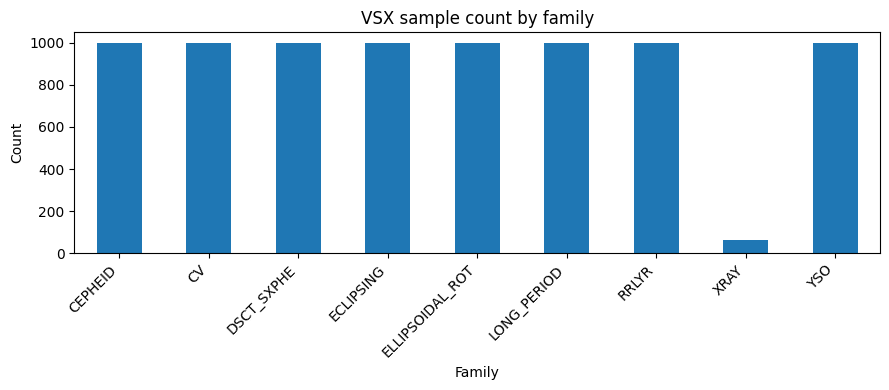

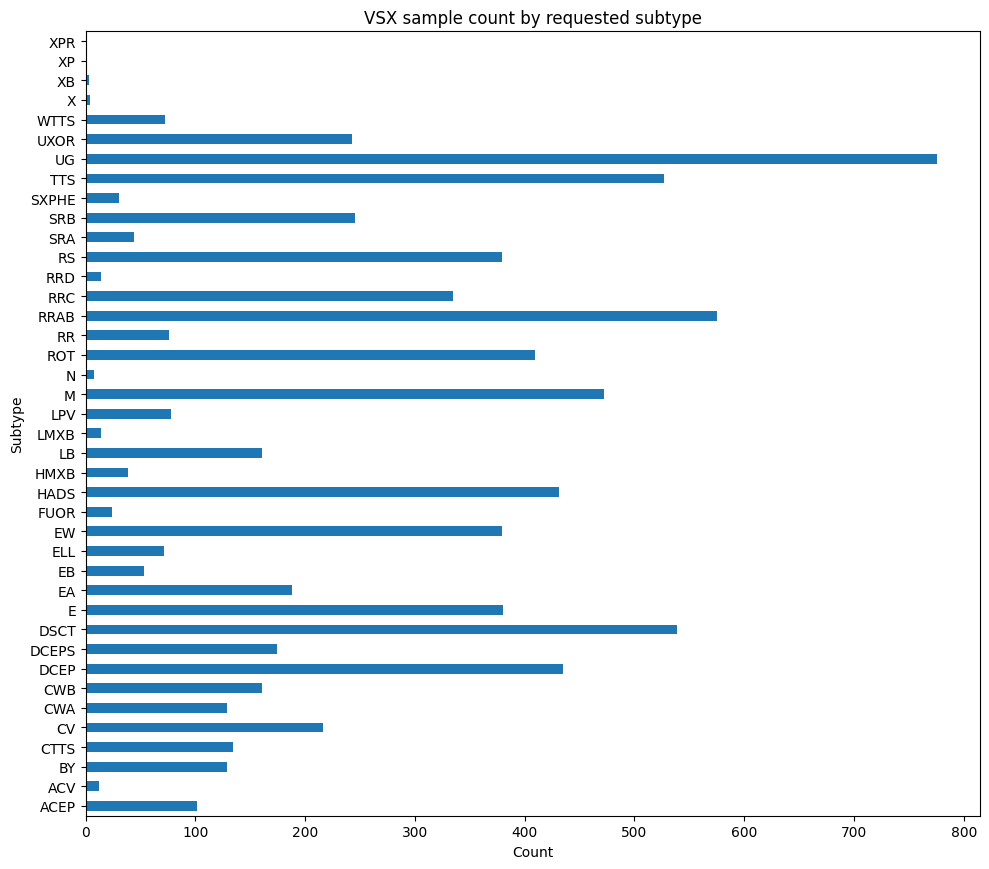

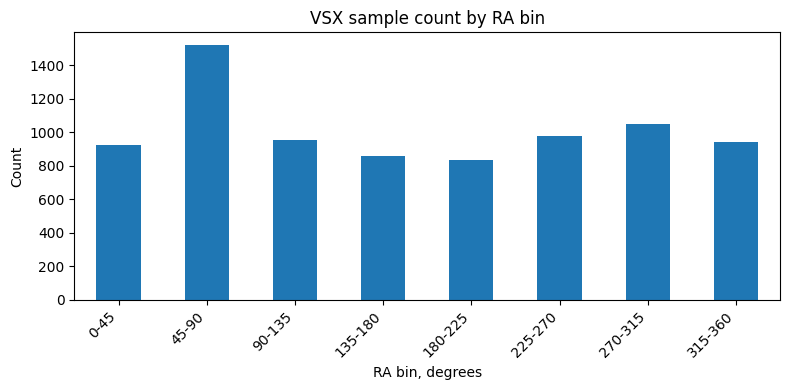

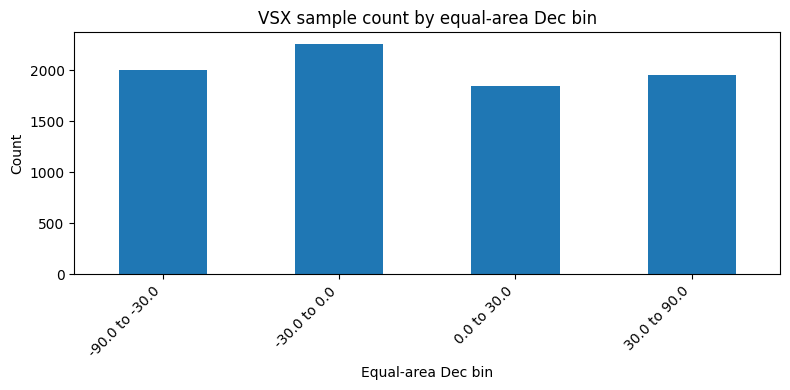

In [8]:
# VSX sample-balance validation
# This cell validates the pure VSX sample before any TESS/TIC matching occurs.

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def vsx_categories_to_dataframe(category_dictionary):
    """Convert VSXCategoryLoader output into a flat DataFrame."""
    if not category_dictionary:
        return pd.DataFrame()

    rows = []
    for family, stars in category_dictionary.items():
        for star in stars:
            row = dict(star)
            row["family"] = row.get("family", family)
            rows.append(row)
    return pd.DataFrame(rows)


def load_vsx_sample_for_validation(pipeline=None):
    """Load the VSX-level sample for balance validation."""
    if pipeline is not None:
        category_dictionary = getattr(pipeline, "vsxCategoryDictionary", None)
        df = vsx_categories_to_dataframe(category_dictionary)
        if not df.empty:
            return df, "current pure VSX query sample"

    if os.path.exists(VSX_METADATA_FILE):
        return pd.read_parquet(VSX_METADATA_FILE), f"pure VSX metadata: {VSX_METADATA_FILE}"

    return pd.DataFrame(), "no available pure VSX sample"


def add_vsx_balance_bins(df, n_ra_bins=8, n_dec_bins=4):
    """Add RA bins and equal-area Dec bins based on uniform spacing in sin(dec)."""
    df = df.copy()
    df["raDeg"] = pd.to_numeric(df.get("raDeg"), errors="coerce")
    df["decDeg"] = pd.to_numeric(df.get("decDeg"), errors="coerce")
    df = df.dropna(subset=["family", "raDeg", "decDeg"])

    ra_edges = np.linspace(0.0, 360.0, n_ra_bins + 1)
    ra_labels = [f"{ra_edges[i]:.0f}-{ra_edges[i + 1]:.0f}" for i in range(n_ra_bins)]
    df["raBin"] = pd.cut(
        df["raDeg"] % 360.0,
        bins=ra_edges,
        labels=ra_labels,
        include_lowest=True,
        right=False,
    )

    sin_dec_edges = np.linspace(-1.0, 1.0, n_dec_bins + 1)
    dec_edges = np.rad2deg(np.arcsin(sin_dec_edges))
    dec_labels = [f"{dec_edges[i]:.1f} to {dec_edges[i + 1]:.1f}" for i in range(n_dec_bins)]
    sin_dec = np.sin(np.deg2rad(df["decDeg"]))
    df["decEqualAreaBin"] = pd.cut(
        sin_dec,
        bins=sin_dec_edges,
        labels=dec_labels,
        include_lowest=True,
    )

    if "requestedVsxType" in df.columns:
        df["sampleSubtype"] = df["requestedVsxType"].fillna(df.get("VSXType"))
    elif "VSXType" in df.columns:
        df["sampleSubtype"] = df["VSXType"]
    else:
        df["sampleSubtype"] = "UNKNOWN"

    return df


def display_vsx_balance_tables(df):
    """Display compact tables for family, subtype, and RA/Dec balance."""
    family_counts = (
        df.groupby("family")
        .size()
        .rename("count")
        .sort_values(ascending=False)
        .reset_index()
    )

    subtype_counts = (
        df.groupby(["family", "sampleSubtype"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["family", "count"], ascending=[True, False])
    )

    sky_counts = pd.crosstab(
        df["decEqualAreaBin"],
        df["raBin"],
        margins=True,
        margins_name="Total",
    )

    balance_summary = pd.DataFrame({
        "metric": [
            "total rows",
            "families",
            "subtypes",
            "non-empty RA bins",
            "non-empty equal-area Dec bins",
            "non-empty RA/Dec cells",
        ],
        "value": [
            len(df),
            df["family"].nunique(),
            df["sampleSubtype"].nunique(),
            df["raBin"].nunique(),
            df["decEqualAreaBin"].nunique(),
            df.groupby(["raBin", "decEqualAreaBin"], observed=True).size().shape[0],
        ],
    })

    display(balance_summary)
    display(family_counts)
    display(subtype_counts)
    display(sky_counts)


def plot_vsx_balance(df):
    """Plot family, subtype, RA, Dec, and sky-position balance."""
    family_counts = df["family"].value_counts().sort_index()
    plt.figure(figsize=(9, 4))
    family_counts.plot(kind="bar")
    plt.title("VSX sample count by family")
    plt.xlabel("Family")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    subtype_counts = df["sampleSubtype"].value_counts().sort_index()
    plt.figure(figsize=(10, max(4, 0.22 * len(subtype_counts))))
    subtype_counts.plot(kind="barh")
    plt.title("VSX sample count by requested subtype")
    plt.xlabel("Count")
    plt.ylabel("Subtype")
    plt.tight_layout()
    plt.show()

    ra_counts = df["raBin"].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    ra_counts.plot(kind="bar")
    plt.title("VSX sample count by RA bin")
    plt.xlabel("RA bin, degrees")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    dec_counts = df["decEqualAreaBin"].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    dec_counts.plot(kind="bar")
    plt.title("VSX sample count by equal-area Dec bin")
    plt.xlabel("Equal-area Dec bin")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


vsx_validation_df, vsx_validation_source = load_vsx_sample_for_validation(pipeline=globals().get("pipeline"))
print("VSX validation source:", vsx_validation_source)

if vsx_validation_df.empty:
    print("No VSX sample available. Run the pure VSX query cell or provide VSX_METADATA_FILE.")
else:
    vsx_validation_df = add_vsx_balance_bins(vsx_validation_df)
    print("Rows available for VSX balance validation:", len(vsx_validation_df))
    display_vsx_balance_tables(vsx_validation_df)
    plot_vsx_balance(vsx_validation_df)


## 2.10 TESS/TIC Direct Match

This cell reads the already-saved pure VSX file from `VSX_METADATA_FILE`, performs only the TIC cross-match and SPOC/QLP availability inspection, and saves the metadata result to `VSX_TESS_MATCH_METADATA_FILE`.

It does not download or extract light curves. That later light-curve step should use `VSX_TESS_MATCH_METADATA_FILE` as input.


In [11]:
# Optional pure TESS/TIC match cell.
# This cell does nothing unless RUN_TESS_MATCH is True.

if RUN_TESS_MATCH:
    if 'pipeline' not in globals():
        vsx_loader = VSXCategoryLoader(
            cacheFolder=VSX_CACHE_FOLDER,
            refreshCache=False,
        )
        tess_converter = VSX2TESSConverter()
        pipeline = ResearchPipeline(
            vsxLoader=vsx_loader,
            tessConverter=tess_converter,
            nFamilies=None,
            nInstances=1000,
            vsxCacheFolder=VSX_CACHE_FOLDER,
            tessCacheFolder=TESS_CACHE_FOLDER,
        )

    tess_match_metadata = pipeline.matchTessOnly(
        vsxMetadataFile=VSX_METADATA_FILE,
        tessMatchMetadataFile=VSX_TESS_MATCH_METADATA_FILE,
        radiusArcsec=RADIUS_ARCSEC,
        maxMatches=MAX_TIC_CANDIDATES,
    )
    tess_match_df = pd.read_parquet(VSX_TESS_MATCH_METADATA_FILE)
    print("Pure TESS/TIC match complete.")
    print("Rows with at least one TIC candidate:", len(tess_match_df))
    print("Saved TESS match metadata to:", VSX_TESS_MATCH_METADATA_FILE)
else:
    print("RUN_TESS_MATCH is False; pure TESS/TIC match was not executed.")
    if os.path.exists(VSX_TESS_MATCH_METADATA_FILE):
        print("Existing TESS match metadata file:", VSX_TESS_MATCH_METADATA_FILE)
    else:
        print("No existing VSX_TESS_MATCH_METADATA_FILE found yet:", VSX_TESS_MATCH_METADATA_FILE)


INFO:root:Crossmatching cached VSX metadata to TIC
INFO:root:Crossmatching family 'CEPHEID' with 1000 stars
INFO:root:Crossmatching family 'CV' with 1000 stars
INFO:root:Crossmatching family 'DSCT_SXPHE' with 1000 stars
INFO:root:Crossmatching family 'ECLIPSING' with 1000 stars
INFO:root:Crossmatching family 'ELLIPSOIDAL_ROT' with 1000 stars
INFO:root:Crossmatching family 'LONG_PERIOD' with 1000 stars
INFO:root:Crossmatching family 'RRLYR' with 1000 stars
INFO:root:Crossmatching family 'XRAY' with 62 stars
INFO:root:Crossmatching family 'YSO' with 1000 stars
INFO:root:Wrote 7672 rows to /data/projects/TESS-research/data_pipeline/TESSCache/VSX_TESS_MATCH_Metadata.parquet


Pure TESS/TIC match complete.
Rows with at least one TIC candidate: 7672
Saved TESS match metadata to: /data/projects/TESS-research/data_pipeline/TESSCache/VSX_TESS_MATCH_Metadata.parquet


## 2.11 Light-Curve Acquisition and Photometric Provenance

Each variable star from the already-matched VSX/TIC metadata table is passed to the light-curve acquisition step. The downloader searches the retained TIC candidates sequentially and uses the fallback order **SPOC → QLP → TESSCut**. Under the updated fallback logic, TESSCut extraction is centered on the original VSX RA/Dec.

This step reads `VSX_TESS_MATCH_METADATA_FILE` and writes `AUGMENTED_METADATA_FILE`.


### Class Definition: TESS light-curve acquisition

The full downloader class definition is included below and collapsed by default.


In [12]:
# TESS light-curve download and SPOC -> QLP -> TESSCut fallback logic

import pandas as pd
import lightkurve as lk
import logging
import os
import glob
import re
import sys
import time
import shutil
import io
import numpy as np
import threading
import warnings
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.io import fits
from contextlib import redirect_stderr, redirect_stdout
from concurrent.futures import ThreadPoolExecutor, as_completed


class _QualityMaskLogFilter(logging.Filter):
    """
    Drops quality-mask log records emitted by Lightkurve below a given
    ignored-cadence percentage threshold, and updates downloader quality.
    """
    _PATTERN = re.compile(
        r"([0-9]+(?:\.[0-9]+)?)%.*cadences will be ignored due to the quality mask",
        re.IGNORECASE,
    )

    def __init__(self, thresholdPercent=20.0, downloader=None):
        super().__init__()
        self.thresholdPercent = thresholdPercent
        self.downloader = downloader

    def filter(self, record):
        message = record.getMessage()
        match = self._PATTERN.search(message)
        if match is not None:
            percentage = float(match.group(1))
            if self.downloader is not None:
                self.downloader._updateStarQuality(percentage)
            return percentage > self.thresholdPercent
        return True


_qualityMaskLogFilter = _QualityMaskLogFilter(thresholdPercent=20.0, downloader=None)
for _lkLoggerName in (
    "lightkurve",
    "lightkurve.io",
    "lightkurve.lightcurve",
    "lightkurve.utils",
    "lightkurve.search",
    "lightkurve.targetpixelfile",
):
    logging.getLogger(_lkLoggerName).addFilter(_qualityMaskLogFilter)

class TessDataDownloader:
    """
    A class to download TESS light curve data organized by stellar categories.
    """
    
    def __init__(self, tessCacheFolder='TESSCache'):
        """Initialize the TessDataDownloader."""
        self.logger = logging.getLogger("TessDataDownloader")
        self.tessCacheFolder = tessCacheFolder
        self.normalizationStdFloor = 1e-8
        self.lowSnrThreshold = 3.0
        if not os.path.exists(self.tessCacheFolder):
            os.makedirs(self.tessCacheFolder)

        self.ignoredCadenceWarningThresholdPercent = 20.0
        self._threadState = threading.local()
        self._workerDownloadsRoot = os.path.join(self.tessCacheFolder, "_worker_downloads")
        
        global _qualityMaskLogFilter
        _qualityMaskLogFilter.downloader = self

    def preprocessLightCurve(
        self,
        lightCurve,
        doRemoveNans=True,
        doNormalize=True,
        doFlatten=False,
        flattenWindowLength=401,
        doRemoveOutliers=False,
        sigma=5.0,
        doBin=False,
        timeBinSize=0.01,
    ):
        """
        Standard preprocessing helper for TESS light curves.

        Keep this configurable because different science cases benefit from
        different preprocessing choices.
        """
        if lightCurve is None:
            return None

        processed = lightCurve
        normalizationMetadata = None

        try:
            if doRemoveNans:
                processed = processed.remove_nans()

            if doNormalize:
                processed, normalizationMetadata = self._standardizeLightCurve(processed)
                if processed is None:
                    return None

            if doFlatten:
                processed = processed.flatten(window_length=flattenWindowLength)

            if doRemoveOutliers:
                processed = processed.remove_outliers(sigma=sigma)

            if doBin:
                processed = processed.bin(time_bin_size=timeBinSize)

            if doRemoveNans:
                processed = processed.remove_nans()

        except Exception as exc:
            self.logger.warning("preprocessLightCurve failed: %s", exc)
            return None

        return processed

    def _resolveMetadataPath(self, tessMetadataParquet):
        if os.path.isabs(tessMetadataParquet):
            return tessMetadataParquet

        cachePath = os.path.join(self.tessCacheFolder, tessMetadataParquet)
        if os.path.exists(cachePath):
            return cachePath

        return tessMetadataParquet

    def _cleanupTransientDownloads(self, downloadRoot=None):
        rootPath = downloadRoot or self.tessCacheFolder
        transientPaths = [
            os.path.join(rootPath, "mastDownload"),
            os.path.join(rootPath, "tesscut"),
        ]

        for transientPath in transientPaths:
            if not os.path.exists(transientPath):
                continue

            try:
                shutil.rmtree(transientPath)
            except Exception as exc:
                self.logger.warning(
                    "Failed to remove transient download directory %s: %s",
                    transientPath,
                    exc,
                )

    def _resetStarQuality(self):
        self._threadState.currentStarQuality = "missing"

    def _getCurrentStarQuality(self):
        return getattr(self._threadState, "currentStarQuality", "missing")

    def _normalizeTicId(self, value):
        if value is None:
            return None

        try:
            if pd.isna(value):
                return None
        except TypeError:
            pass

        digits = "".join(ch for ch in str(value) if ch.isdigit())
        if not digits:
            return None

        return str(int(digits))

    def _sanitizeFilenameComponent(self, value):
        """Sanitize a string for use in filenames by replacing spaces and special chars with underscores."""
        if value is None:
            return None
        # Replace spaces and other problematic characters with underscores
        sanitized = str(value).replace(" ", "_").replace(",", "_").replace(":", "_")
        return sanitized

    def _sortedTicCandidates(self, ticCandidates):
        if ticCandidates is None:
            return []

        if isinstance(ticCandidates, float) and pd.isna(ticCandidates):
            return []

        if hasattr(ticCandidates, "tolist"):
            ticCandidates = ticCandidates.tolist()

        if isinstance(ticCandidates, dict):
            ticCandidates = [ticCandidates]

        normalizedCandidates = []
        for candidate in ticCandidates or []:
            if candidate is None:
                continue
            normalizedCandidates.append(dict(candidate))

        normalizedCandidates.sort(
            key=lambda candidate: float(candidate.get("ticDistanceArcmin", float("inf")))
        )
        return normalizedCandidates

    def _logDuplicateTicMappings(self, df):
        """Log stars that map to the same top TIC candidate."""
        starsByTopTic = {}
        duplicateWarningCount = 0

        for _, row in df.iterrows():
            ticCandidates = self._sortedTicCandidates(row.get("ticCandidates"))
            topTic = self._normalizeTicId((ticCandidates[0] if ticCandidates else {}).get("ticId"))
            if topTic is None:
                continue

            candidateTics = [
                self._normalizeTicId(candidate.get("ticId"))
                for candidate in ticCandidates
            ]
            candidateTics = [tic for tic in candidateTics if tic is not None]

            starsByTopTic.setdefault(topTic, []).append(
                {
                    "family": row.get("family"),
                    "VSXType": row.get("VSXType"),
                    "VSXId": row.get("VSXId"),
                    "tics": candidateTics,
                }
            )

        for topTic, stars in starsByTopTic.items():
            if len(stars) < 2:
                continue
            for star in stars:
                self.logger.error(
                    "Duplicate TIC mapping detected: TIC=%s family=%s vsxtype=%s vsxid=%s tics=%s",
                    topTic,
                    star.get("family"),
                    star.get("VSXType"),
                    star.get("VSXId"),
                    star.get("tics"),
                )
                duplicateWarningCount += 1

        return duplicateWarningCount

    def _standardizeLightCurve(self, lightCurve):
        if not RUN_LIGHT_CURVE_STANDARDIZATION:
            return lightCurve, None
        
        if lightCurve is None:
            return None, None

        cleanedLightCurve = lightCurve.remove_nans()
        if len(cleanedLightCurve) == 0:
            return None, {
                "normalizationApplied": False,
                "fluxMedian": None,
                "fluxStd": None,
                "fluxSnr": None,
                "medianUnstable": True,
                "lowSNR": True,
                "lowQualityLightCurve": True,
                "lowQualityReason": "No valid cadences after removing NaNs",
                "validCadenceCount": 0,
            }

        fluxArray = np.asarray(getattr(cleanedLightCurve.flux, "value", cleanedLightCurve.flux), dtype=float)
        validMask = np.isfinite(fluxArray)

        fluxMask = getattr(cleanedLightCurve.flux, "mask", None)
        if fluxMask is not None:
            fluxMaskArray = np.asarray(fluxMask, dtype=bool)
            if fluxMaskArray.shape == ():
                validMask &= (not bool(fluxMaskArray))
            else:
                validMask &= np.logical_not(fluxMaskArray)

        if hasattr(cleanedLightCurve.time, "value"):
            timeValues = np.asarray(cleanedLightCurve.time.value, dtype=float)
            validMask &= np.isfinite(timeValues)

        validFlux = fluxArray[validMask]
        if validFlux.size == 0:
            return None, {
                "normalizationApplied": False,
                "fluxMedian": None,
                "fluxStd": None,
                "fluxSnr": None,
                "medianUnstable": True,
                "lowSNR": True,
                "lowQualityLightCurve": True,
                "lowQualityReason": "No valid cadences after masking invalid flux values",
                "validCadenceCount": 0,
            }

        medianFlux = float(np.nanmedian(validFlux))
        stdFlux = float(np.nanstd(validFlux))
        medianUnstable = (not np.isfinite(medianFlux)) or abs(medianFlux) < self.normalizationStdFloor
        lowStd = (not np.isfinite(stdFlux)) or stdFlux < self.normalizationStdFloor
        fluxSnr = None if lowStd else float(abs(medianFlux) / stdFlux)
        lowSNR = fluxSnr is None or fluxSnr < self.lowSnrThreshold

        normalizationMetadata = {
            "normalizationApplied": False,
            "fluxMedian": medianFlux,
            "fluxStd": stdFlux,
            "fluxSnr": fluxSnr,
            "medianUnstable": bool(medianUnstable),
            "lowSNR": bool(lowSNR),
            "lowQualityLightCurve": bool(medianUnstable or lowSNR or lowStd),
            "lowQualityReason": None,
            "validCadenceCount": int(validFlux.size),
        }

        if lowStd:
            normalizationMetadata["lowQualityReason"] = "Flux standard deviation is too small for stable normalization"
            return cleanedLightCurve, normalizationMetadata

        standardizedFlux = np.full_like(fluxArray, np.nan, dtype=float)
        standardizedFlux[validMask] = (fluxArray[validMask] - medianFlux) / stdFlux

        standardizedLightCurve = cleanedLightCurve.copy()
        standardizedLightCurve.flux = standardizedFlux * u.dimensionless_unscaled

        if hasattr(standardizedLightCurve, "flux_err") and standardizedLightCurve.flux_err is not None:
            fluxErrArray = np.asarray(
                getattr(standardizedLightCurve.flux_err, "value", standardizedLightCurve.flux_err),
                dtype=float,
            )
            standardizedFluxErr = np.full_like(fluxErrArray, np.nan, dtype=float)
            finiteFluxErr = np.isfinite(fluxErrArray)
            standardizedFluxErr[finiteFluxErr] = fluxErrArray[finiteFluxErr] / stdFlux
            standardizedLightCurve.flux_err = standardizedFluxErr * u.dimensionless_unscaled

        normalizationMetadata["normalizationApplied"] = True
        return standardizedLightCurve.remove_nans(), normalizationMetadata

    def _storeLightCurve(self, lightCurve, outputFile, ticId, authorLabel):
        try:
            lightCurve.to_fits(path=outputFile, overwrite=True)
        except (AttributeError, ValueError) as exc:
            self.logger.warning(
                "to_fits failed for TIC %s author %s, using fallback: %s",
                ticId,
                authorLabel,
                exc,
            )
            try:
                timeCol = fits.Column(name="TIME", format="D", array=lightCurve.time.jd)
                fluxCol = fits.Column(name="FLUX", format="E", array=np.asarray(lightCurve.flux.value, dtype=float))
                cols = fits.ColDefs([timeCol, fluxCol])
                hdu = fits.BinTableHDU.from_columns(cols)
                hdu.writeto(outputFile, overwrite=True)
            except Exception as fallbackExc:
                self.logger.error(
                    "Fallback FITS write also failed for TIC %s author %s: %s",
                    ticId,
                    authorLabel,
                    fallbackExc,
                )
                return False

        return True

    def _categorizeQualityMaskPercentage(self, percentage):
        """Categorize data quality based on quality_bitmask cadence percentage."""
        if percentage < 10:
            return "clean"
        elif percentage < 25:
            return "acceptable"
        elif percentage < 40:
            return "caution"
        else:
            return "poor"

    def _updateStarQuality(self, percentage):
        """Update current star quality to worst quality seen so far."""
        newQuality = self._categorizeQualityMaskPercentage(percentage)
        qualityOrder = {"clean": 0, "acceptable": 1, "caution": 2, "poor": 3}
        currentQuality = self._getCurrentStarQuality()
        if qualityOrder.get(newQuality, 0) > qualityOrder.get(currentQuality, 0):
            self._threadState.currentStarQuality = newQuality

    def _finalizeStarQuality(self, lightCurveAvailable):
        """Return final quality after considering whether any light curve was available."""
        if not lightCurveAvailable:
            return "missing"

        if self._getCurrentStarQuality() == "missing":
            return "clean"

        return self._getCurrentStarQuality()

    def _runWithFilteredWarnings(self, func, *args, ticId=None, warningContext=None, **kwargs):
        qualityWarningPattern = re.compile(
            r"([0-9]+(?:\.[0-9]+)?)%\s*\([^)]*\)\s*of the cadences will be ignored due to the quality mask",
            re.IGNORECASE,
        )
        negativeMedianPattern = re.compile(
            r"negative median flux",
            re.IGNORECASE,
        )
        zeroCenteredPattern = re.compile(
            r"zero-centered.*normalize\(\)",
            re.IGNORECASE,
        )
        boolInversionDeprecationPattern = re.compile(
            r"bitwise inversion\s+['`~]+\s*on bool\s+is deprecated",
            re.IGNORECASE,
        )

        with warnings.catch_warnings(record=True) as caughtWarnings:
            warnings.simplefilter("always")
            result = func(*args, **kwargs)

        for caughtWarning in caughtWarnings:
            warningMessage = str(caughtWarning.message)
            qualityMatch = qualityWarningPattern.search(warningMessage)

            if qualityMatch is not None:
                ignoredPercent = float(qualityMatch.group(1))
                self._updateStarQuality(ignoredPercent)
                if ignoredPercent > self.ignoredCadenceWarningThresholdPercent:
                    self.logger.warning(
                        "High quality-mask rejection for TIC %s%s: %s",
                        ticId if ticId is not None else "unknown",
                        f" during {warningContext}" if warningContext else "",
                        warningMessage,
                    )
                continue

            if negativeMedianPattern.search(warningMessage) is not None:
                continue

            if zeroCenteredPattern.search(warningMessage) is not None:
                continue

            if boolInversionDeprecationPattern.search(warningMessage) is not None:
                continue

            self.logger.warning(
                "Warning for TIC %s%s: %s",
                ticId if ticId is not None else "unknown",
                f" during {warningContext}" if warningContext else "",
                warningMessage,
            )

        return result

    def _lightCurveFromSearchResult(self, searchResult, ticId=None, downloadDir=None):
        if searchResult is None or len(searchResult) == 0:
            return None

        resolvedDownloadDir = downloadDir or self.tessCacheFolder

        try:
            downloaded = self._runWithFilteredWarnings(
                searchResult.download_all,
                download_dir=resolvedDownloadDir,
                ticId=ticId,
                warningContext="search_lightcurve download_all",
            )
        except Exception:
            downloaded = self._runWithFilteredWarnings(
                searchResult.download,
                download_dir=resolvedDownloadDir,
                ticId=ticId,
                warningContext="search_lightcurve download",
            )

        if downloaded is None:
            return None

        if isinstance(downloaded, lk.LightCurveCollection):
            if len(downloaded) == 0:
                return None
            try:
                return downloaded.stitch()
            except Exception as exc:
                self.logger.warning("Failed to stitch light-curve collection: %s", exc)
                return downloaded[0]

        return downloaded

    def _runQuietLightkurveSearch(self, searchFn, *args, **kwargs):
        loggerNames = [
            "lightkurve.search",
            "astroquery",
            "astroquery.mast",
        ]
        loggerState = []

        for loggerName in loggerNames:
            packageLogger = logging.getLogger(loggerName)
            loggerState.append((packageLogger, packageLogger.level, packageLogger.disabled))
            packageLogger.setLevel(logging.CRITICAL + 1)

        try:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                return searchFn(*args, **kwargs)
        finally:
            for packageLogger, level, disabled in loggerState:
                packageLogger.setLevel(level)
                packageLogger.disabled = disabled

    def _downloadCatalogLightCurve(self, ticId, author, downloadDir=None, vsxId=None):
        try:
            searchResult = self._runQuietLightkurveSearch(
                lk.search_lightcurve,
                f"TIC {ticId}",
                mission="TESS",
                author=author,
            )
        except Exception as exc:
            self.logger.warning(
                "search_lightcurve failed for TIC %s author %s: %s",
                ticId,
                author,
                exc,
            )
            return None

        if searchResult is None or len(searchResult) == 0:
            return None

        lightCurve = self._lightCurveFromSearchResult(
            searchResult,
            ticId=ticId,
            downloadDir=downloadDir,
        )
        if lightCurve is None:
            return None

        # Save raw light curve
        sanitizedVsxId = self._sanitizeFilenameComponent(vsxId)
        vsxIdStr = f"VSX_{sanitizedVsxId}_" if sanitizedVsxId else ""
        rawOutputFile = os.path.join(self.tessCacheFolder, f"{vsxIdStr}TIC_{ticId}_{author}_raw.fits")
        if not self._storeLightCurve(lightCurve, rawOutputFile, ticId, f"{author}_raw"):
            return None

        # Standardize light curve
        standardizedLightCurve, normalizationMetadata = self._standardizeLightCurve(lightCurve)
        if standardizedLightCurve is None:
            return None

        # Save standardized light curve
        standardizedOutputFile = os.path.join(self.tessCacheFolder, f"{vsxIdStr}TIC_{ticId}_{author}_standardized.fits")
        if not self._storeLightCurve(standardizedLightCurve, standardizedOutputFile, ticId, f"{author}_standardized"):
            return None

        sectors = []
        if hasattr(searchResult, "table") and "sequence_number" in searchResult.table.colnames:
            sectors = [
                int(sector)
                for sector in searchResult.table["sequence_number"]
                if sector is not None and str(sector) != "--"
            ]

        return {
            "bestMatch": {"ticId": ticId, "author": author},
            "provenance": author,
            "lightCurvePath": standardizedOutputFile,  # Standardized by default
            "rawLightCurvePath": rawOutputFile,
            "lightCurveAvailable": True,
            "extractionMetadata": {
                "downloadMethod": "search_lightcurve",
                "author": author,
                "productCount": int(len(searchResult)),
                "sectors": sectors,
                "fluxNormalization": normalizationMetadata,
            },
            "normalizationApplied": normalizationMetadata["normalizationApplied"],
            "fluxMedian": normalizationMetadata["fluxMedian"],
            "fluxStd": normalizationMetadata["fluxStd"],
            "fluxSnr": normalizationMetadata["fluxSnr"],
            "medianUnstable": normalizationMetadata["medianUnstable"],
            "lowSNR": normalizationMetadata["lowSNR"],
            "lowQualityLightCurve": normalizationMetadata["lowQualityLightCurve"],
            "lowQualityReason": normalizationMetadata["lowQualityReason"],
        }

    def _extractTessCutLightCurve(self, starRecord, ticCandidates, cutoutSize, downloadDir=None):
        selectedCandidate = {}
        selectedCandidateRank = None

        sortedCandidates = self._sortedTicCandidates(ticCandidates)

        # Use the first TIC candidate that has both coordinates populated.
        for rank, candidate in enumerate(sortedCandidates, start=1):
            candidateRaDeg = candidate.get("ticRaDeg")
            candidateDecDeg = candidate.get("ticDecDeg")
            if candidateRaDeg is None or candidateDecDeg is None:
                continue
            selectedCandidate = candidate
            selectedCandidateRank = rank
            break

        # Preserve prior behavior for TIC-based metadata if no candidate had usable coordinates.
        if not selectedCandidate:
            selectedCandidate = (sortedCandidates[0] if sortedCandidates else {})

        sourceRaDeg = starRecord.get("raDeg")
        sourceDecDeg = starRecord.get("decDeg")

        self.logger.info(
            "TESSCut centered on original VSX coords for VSX=%s: raDeg=%s decDeg=%s selectedCandidateRank=%s TIC=%s distance=%s arcmin",
            starRecord.get("VSXId"),
            sourceRaDeg,
            sourceDecDeg,
            selectedCandidateRank,
            selectedCandidate.get("ticId"),
            selectedCandidate.get("ticDistanceArcmin"),
        )

        if sourceRaDeg is None or sourceDecDeg is None:
            return None

        resolvedDownloadDir = downloadDir or self.tessCacheFolder

        try:
            coord = SkyCoord(ra=float(sourceRaDeg) * u.deg, dec=float(sourceDecDeg) * u.deg, frame="icrs")
        except Exception as exc:
            self.logger.warning(
                "Invalid sky coordinates for %s: %s",
                starRecord.get("VSXName", starRecord.get("VSXId", "unknown")),
                exc,
            )
            return None

        try:
            searchResult = self._runQuietLightkurveSearch(lk.search_tesscut, coord)
        except Exception as exc:
            self.logger.warning(
                "search_tesscut failed for %s: %s",
                starRecord.get("VSXName", starRecord.get("VSXId", "unknown")),
                exc,
            )
            return None

        if searchResult is None or len(searchResult) == 0:
            return None

        try:
            tpfCollection = self._runWithFilteredWarnings(
                searchResult.download_all,
                cutout_size=cutoutSize,
                download_dir=resolvedDownloadDir,
                ticId=self._normalizeTicId(selectedCandidate.get("ticId")),
                warningContext="search_tesscut download_all",
            )
        except Exception as exc:
            self.logger.warning(
                "TESSCut download failed for %s: %s",
                starRecord.get("VSXName", starRecord.get("VSXId", "unknown")),
                exc,
            )
            return None

        if tpfCollection is None or len(tpfCollection) == 0:
            return None

        extractedCurves = []
        aperturePixelCounts = []
        sectors = []

        for tpf in tpfCollection:
            try:
                apertureMask = tpf.create_threshold_mask(threshold=3, reference_pixel="center")
                if apertureMask is None or not np.any(apertureMask):
                    apertureMask = np.zeros(tpf.flux[0].shape, dtype=bool)
                    apertureMask[apertureMask.shape[0] // 2, apertureMask.shape[1] // 2] = True

                lightCurve = self._runWithFilteredWarnings(
                    tpf.to_lightcurve,
                    aperture_mask=apertureMask,
                    ticId=self._normalizeTicId(selectedCandidate.get("ticId")),
                    warningContext="TESSCut to_lightcurve",
                ).remove_nans()
                if len(lightCurve) == 0:
                    continue

                extractedCurves.append(lightCurve)
                aperturePixelCounts.append(int(np.sum(apertureMask)))

                sector = getattr(tpf, "sector", None)
                if sector is not None:
                    sectors.append(int(sector))
            except Exception as exc:
                self.logger.warning(
                    "Aperture photometry failed for %s in one TESSCut sector: %s",
                    starRecord.get("VSXName", starRecord.get("VSXId", "unknown")),
                    exc,
                )
            finally:
                try:
                    if hasattr(tpf, "close") and callable(tpf.close):
                        tpf.close()
                    elif hasattr(tpf, "hdu") and hasattr(tpf.hdu, "close"):
                        tpf.hdu.close()
                except Exception as closeExc:
                    self.logger.debug("Failed to close TESSCut handle cleanly: %s", closeExc)

        if not extractedCurves:
            return None

        if len(extractedCurves) == 1:
            stitched = extractedCurves[0]
        else:
            try:
                stitched = lk.LightCurveCollection(extractedCurves).stitch()
            except Exception as exc:
                self.logger.warning("Failed to stitch TESSCut light curves: %s", exc)
                stitched = extractedCurves[0]

        stitched = stitched.remove_nans()
        if len(stitched) == 0:
            return None

        # Save raw light curve
        chosenTicId = self._normalizeTicId(selectedCandidate.get("ticId")) or "NA"
        vsxId = starRecord.get("VSXId", "NA")
        sanitizedVsxId = self._sanitizeFilenameComponent(vsxId)
        rawOutputFile = os.path.join(self.tessCacheFolder, f"VSX_{sanitizedVsxId}_TIC_{chosenTicId}_TESSCut_raw.fits")
        if not self._storeLightCurve(stitched, rawOutputFile, chosenTicId, "TESSCut_raw"):
            return None

        # Standardize light curve
        standardizedLightCurve, normalizationMetadata = self._standardizeLightCurve(stitched)
        if standardizedLightCurve is None:
            return None

        # Save standardized light curve
        standardizedOutputFile = os.path.join(self.tessCacheFolder, f"VSX_{sanitizedVsxId}_TIC_{chosenTicId}_TESSCut_standardized.fits")
        if not self._storeLightCurve(standardizedLightCurve, standardizedOutputFile, chosenTicId, "TESSCut_standardized"):
            return None

        return {
            "bestMatch": {"ticId": chosenTicId, "author": "TESSCut"},
            "provenance": "TESSCut",
            "lightCurvePath": standardizedOutputFile,  # Standardized by default
            "rawLightCurvePath": rawOutputFile,
            "lightCurveAvailable": True,
            "extractionMetadata": {
                "downloadMethod": "search_tesscut",
                "sourceRaDeg": float(sourceRaDeg),
                "sourceDecDeg": float(sourceDecDeg),
                "tesscutCenterSource": "VSX",
                "tesscutCenterRaDeg": float(sourceRaDeg),
                "tesscutCenterDecDeg": float(sourceDecDeg),
                "cutoutSize": list(cutoutSize),
                "sectorCount": len(extractedCurves),
                "sectors": sectors,
                "aperturePixelCounts": aperturePixelCounts,
                "selectedCandidateTicId": chosenTicId,
                "selectedCandidateDistanceArcmin": selectedCandidate.get("ticDistanceArcmin"),
                "extractionMethod": "threshold_mask_photometry",
                "fluxNormalization": normalizationMetadata,
            },
            "normalizationApplied": normalizationMetadata["normalizationApplied"],
            "fluxMedian": normalizationMetadata["fluxMedian"],
            "fluxStd": normalizationMetadata["fluxStd"],
            "fluxSnr": normalizationMetadata["fluxSnr"],
            "medianUnstable": normalizationMetadata["medianUnstable"],
            "lowSNR": normalizationMetadata["lowSNR"],
            "lowQualityLightCurve": normalizationMetadata["lowQualityLightCurve"],
            "lowQualityReason": normalizationMetadata["lowQualityReason"],
        }

    def _processSingleStar(self, idx, rowData, count, totalCount, cutoutSize, cleanupDownloads):
        starName = rowData.get("VSXName", rowData.get("VSXId", f"row-{idx}"))
        family = rowData.get("family")
        self.logger.info(
            "Processing star %d/%d: %s (family=%s)",
            count,
            totalCount,
            starName,
            family,
        )

        self._resetStarQuality()
        os.makedirs(self._workerDownloadsRoot, exist_ok=True)
        taskDownloadDir = os.path.join(
            self._workerDownloadsRoot,
            f"star_{idx}_{threading.get_ident()}_{int(time.time() * 1000)}",
        )
        os.makedirs(taskDownloadDir, exist_ok=True)

        updates = {
            "bestMatch": None,
            "provenance": None,
            "lightCurvePath": None,
            "rawLightCurvePath": None,
            "extractionMetadata": None,
            "lightCurveAvailable": False,
            "noLightCurveReason": None,
            "normalizationApplied": None,
            "fluxMedian": None,
            "fluxStd": None,
            "fluxSnr": None,
            "medianUnstable": None,
            "lowSNR": None,
            "lowQualityLightCurve": None,
            "lowQualityReason": None,
            "quality": "missing",
        }

        # Check if files already exist
        vsxId = rowData.get("VSXId")
        if vsxId:
            sanitized = self._sanitizeFilenameComponent(vsxId)
            std_pattern = os.path.join(self.tessCacheFolder, f"VSX_{sanitized}_*standardized.fits")
            std_files = glob.glob(std_pattern)
            if std_files:
                std_path = std_files[0]
                raw_path = std_path.replace('_standardized.fits', '_raw.fits')
                if os.path.exists(raw_path):
                    updates["lightCurvePath"] = std_path
                    updates["rawLightCurvePath"] = raw_path
                    updates["lightCurveAvailable"] = True
                    updates["provenance"] = "existing"
                    updates["quality"] = "existing"
                    self.logger.info("Skipping %s: files already exist", starName)
                    return idx, updates

        ticCandidates = self._sortedTicCandidates(rowData.get("ticCandidates"))
        preferredTicId = self._normalizeTicId(
            (ticCandidates[0] if ticCandidates else {}).get("ticId")
        )
        matchedResult = None

        try:
            def _starTask():
                nonlocal matchedResult

                for candidate in ticCandidates:
                    ticId = self._normalizeTicId(candidate.get("ticId"))
                    if ticId is None:
                        continue

                    for author in ("SPOC", "QLP"):
                        matchedResult = self._downloadCatalogLightCurve(
                            ticId,
                            author,
                            downloadDir=taskDownloadDir,
                            vsxId=rowData.get("VSXId"),
                        )
                        if matchedResult is None:
                            continue

                        matchedResult["bestMatch"]["ticDistanceArcmin"] = candidate.get("ticDistanceArcmin")
                        matchedResult["bestMatch"]["ticRaDeg"] = candidate.get("ticRaDeg")
                        matchedResult["bestMatch"]["ticDecDeg"] = candidate.get("ticDecDeg")
                        matchedResult["bestMatch"]["ticTmag"] = candidate.get("ticTmag")
                        matchedResult["extractionMetadata"]["selectedCandidate"] = dict(candidate)
                        return

                matchedResult = self._extractTessCutLightCurve(
                    rowData,
                    ticCandidates,
                    cutoutSize,
                    downloadDir=taskDownloadDir,
                )

            self._runWithFilteredWarnings(
                _starTask,
                ticId=preferredTicId,
                warningContext="star processing",
            )

            if matchedResult is None:
                self.logger.error(
                    "No usable TESS light curve found for %s after SPOC, QLP, and TESSCut attempts",
                    starName,
                )
                updates["noLightCurveReason"] = (
                    "No SPOC/QLP light curve and no usable TESSCut extraction"
                )
                updates["quality"] = self._finalizeStarQuality(False)
                return idx, updates

            updates.update(
                {
                    "bestMatch": matchedResult["bestMatch"],
                    "provenance": matchedResult["provenance"],
                    "lightCurvePath": matchedResult["lightCurvePath"],
                    "rawLightCurvePath": matchedResult.get("rawLightCurvePath"),
                    "extractionMetadata": matchedResult["extractionMetadata"],
                    "lightCurveAvailable": matchedResult["lightCurveAvailable"],
                    "normalizationApplied": matchedResult.get("normalizationApplied"),
                    "fluxMedian": matchedResult.get("fluxMedian"),
                    "fluxStd": matchedResult.get("fluxStd"),
                    "fluxSnr": matchedResult.get("fluxSnr"),
                    "medianUnstable": matchedResult.get("medianUnstable"),
                    "lowSNR": matchedResult.get("lowSNR"),
                    "lowQualityLightCurve": matchedResult.get("lowQualityLightCurve"),
                    "lowQualityReason": matchedResult.get("lowQualityReason"),
                    "quality": self._finalizeStarQuality(
                        matchedResult.get("lightCurveAvailable", False)
                    ),
                }
            )
            return idx, updates
        finally:
            if cleanupDownloads:
                self._cleanupTransientDownloads(taskDownloadDir)

            try:
                shutil.rmtree(taskDownloadDir)
            except FileNotFoundError:
                pass
            except Exception as exc:
                self.logger.warning(
                    "Failed to remove worker download directory %s: %s",
                    taskDownloadDir,
                    exc,
                )

    def downloadTessLightCurves(
        self,
        tessMetadataParquet,
        augmentedMetadataFile="TESSAugmented.parquet",
        cutoutSize=(15, 15),
        cleanupDownloads=True,
        lowSnrThreshold=None,
        maxWorkers=None,
    ):
        """
        Download or extract TESS light curves for each star in cached metadata.

        The method first tries TIC candidates in angular-separation order using
        SPOC then QLP products. If neither exists, it falls back to TESSCut using
        the original VSX coordinates and writes augmented metadata to parquet.
        """
        if not RUN_TESS_LIGHT_CURVE_DOWNLOAD:
            self.logger.info("TESS light curve download is disabled by configuration. Skipping.")
            return pd.DataFrame()
        originalLowSnrThreshold = self.lowSnrThreshold
        if lowSnrThreshold is not None:
            self.lowSnrThreshold = float(lowSnrThreshold)

        metadataPath = self._resolveMetadataPath(tessMetadataParquet)
        df = pd.read_parquet(metadataPath)

        requiredColumns = {"family", "raDeg", "decDeg", "ticCandidates"}
        missingColumns = requiredColumns - set(df.columns)
        if missingColumns:
            raise ValueError(
                f"Missing required columns in {metadataPath}: {sorted(missingColumns)}"
            )

        # Check if augmented metadata exists to resume from previous run
        augmentedPath = os.path.join(self.tessCacheFolder, augmentedMetadataFile)
        if os.path.exists(augmentedPath):
            self.logger.info("Loading existing augmented metadata from %s to resume processing", augmentedPath)
            df = pd.read_parquet(augmentedPath)
        else:
            # Initialize columns if starting fresh
            for column in [
                "bestMatch",
                "provenance",
                "lightCurvePath",
                "rawLightCurvePath",
                "extractionMetadata",
                "lightCurveAvailable",
                "noLightCurveReason",
                "normalizationApplied",
                "fluxMedian",
                "fluxStd",
                "fluxSnr",
                "medianUnstable",
                "lowSNR",
                "lowQualityLightCurve",
                "lowQualityReason",
                "quality",
            ]:
                if column not in df.columns:
                    df[column] = [None] * len(df)

        duplicateWarningCount = self._logDuplicateTicMappings(df)

        # Only process stars that don't have both raw and standardized files
        orderedIndices = df.sort_values(["family", "VSXName"], na_position="last").index.tolist()
        def has_both_files(row):
            lc_path = row.get("lightCurvePath")
            raw_path = row.get("rawLightCurvePath")
            return lc_path and raw_path and os.path.exists(lc_path) and os.path.exists(raw_path)
        orderedIndices = [idx for idx in orderedIndices if not has_both_files(df.loc[idx])]

        if not orderedIndices:
            self.logger.info("All stars already have light curves available. Skipping download.")
            successCount = int(df["lightCurveAvailable"].eq(True).sum())
            totalCount = int(len(df))
            failedCount = totalCount - successCount
            self.logger.info(
                "Download summary: total=%d succeeded=%d failed=%d duplicateTicWarnings=%d",
                totalCount,
                successCount,
                failedCount,
                duplicateWarningCount,
            )
            return df

        workerCount = maxWorkers
        if workerCount is None:
            workerCount = min(4, max(1, len(orderedIndices)))

        try:
            if workerCount == 1:
                for count, idx in enumerate(orderedIndices, start=1):
                    try:
                        _, updates = self._processSingleStar(
                            idx,
                            df.loc[idx].to_dict(),
                            count,
                            len(orderedIndices),
                            cutoutSize,
                            cleanupDownloads,
                        )
                    except Exception as exc:
                        row = df.loc[idx]
                        starName = row.get("VSXName", row.get("VSXId", f"row-{idx}"))
                        self.logger.exception("Star task failed for %s: %s", starName, exc)
                        updates = {
                            "bestMatch": None,
                            "provenance": None,
                            "lightCurvePath": None,
                            "rawLightCurvePath": None,
                            "extractionMetadata": None,
                            "lightCurveAvailable": False,
                            "noLightCurveReason": f"Worker task failed: {exc}",
                            "normalizationApplied": None,
                            "fluxMedian": None,
                            "fluxStd": None,
                            "fluxSnr": None,
                            "medianUnstable": None,
                            "lowSNR": None,
                            "lowQualityLightCurve": None,
                            "lowQualityReason": None,
                            "quality": "missing",
                        }
                    for column, value in updates.items():
                        df.at[idx, column] = value
                    # Save progress after each star
                    df.to_parquet(augmentedPath, index=False)
            else:
                with ThreadPoolExecutor(max_workers=workerCount) as executor:
                    futureToIdx = {
                        executor.submit(
                            self._processSingleStar,
                            idx,
                            df.loc[idx].to_dict(),
                            count,
                            len(orderedIndices),
                            cutoutSize,
                            cleanupDownloads,
                        ): idx
                        for count, idx in enumerate(orderedIndices, start=1)
                    }

                    for future in as_completed(futureToIdx):
                        idx = futureToIdx[future]
                        try:
                            _, updates = future.result()
                        except Exception as exc:
                            row = df.loc[idx]
                            starName = row.get("VSXName", row.get("VSXId", f"row-{idx}"))
                            self.logger.exception("Star task failed for %s: %s", starName, exc)
                            updates = {
                                "bestMatch": None,
                                "provenance": None,
                                "lightCurvePath": None,
                                "rawLightCurvePath": None,
                                "extractionMetadata": None,
                                "lightCurveAvailable": False,
                                "noLightCurveReason": f"Worker task failed: {exc}",
                                "normalizationApplied": None,
                                "fluxMedian": None,
                                "fluxStd": None,
                                "fluxSnr": None,
                                "medianUnstable": None,
                                "lowSNR": None,
                                "lowQualityLightCurve": None,
                                "lowQualityReason": None,
                                "quality": "missing",
                            }

                        for column, value in updates.items():
                            df.at[idx, column] = value
                        # Save progress after each star
                        df.to_parquet(augmentedPath, index=False)
        finally:
            self.lowSnrThreshold = originalLowSnrThreshold
            if cleanupDownloads:
                self._cleanupTransientDownloads()
            try:
                shutil.rmtree(self._workerDownloadsRoot)
            except FileNotFoundError:
                pass
            except Exception as exc:
                self.logger.warning(
                    "Failed to remove worker download root %s: %s",
                    self._workerDownloadsRoot,
                    exc,
                )

        augmentedPath = os.path.join(self.tessCacheFolder, augmentedMetadataFile)
        df.to_parquet(augmentedPath, index=False)
        successCount = int(df["lightCurveAvailable"].eq(True).sum())
        totalCount = int(len(df))
        failedCount = totalCount - successCount
        self.logger.info(
            "Download summary: total=%d succeeded=%d failed=%d duplicateTicWarnings=%d",
            totalCount,
            successCount,
            failedCount,
            duplicateWarningCount,
        )
        self.logger.info("Saved augmented metadata to %s", augmentedPath)
        return df

In [ ]:
# Optional light-curve download cell.
# This cell does nothing unless RUN_TESS_LIGHT_CURVE_DOWNLOAD is True.

if RUN_TESS_LIGHT_CURVE_DOWNLOAD:
    tess_downloader = TessDataDownloader(tessCacheFolder=TESS_CACHE_FOLDER)
    augmented = tess_downloader.downloadTessLightCurves(
        tessMetadataParquet=VSX_TESS_MATCH_METADATA_FILE,
        augmentedMetadataFile=AUGMENTED_METADATA_FILE,
        cutoutSize=(15, 15),
        cleanupDownloads=True,
        maxWorkers=24,
    )

    print("Light-curve acquisition complete.")
    print("Rows:", len(augmented))
    print("Saved augmented metadata to:", AUGMENTED_METADATA_FILE)
else:
    print("RUN_TESS_LIGHT_CURVE_DOWNLOAD is False; light-curve download was not executed.")


## 2.12 FITS Integrity Checks and Quality Control

Because the dataset depends on thousands of downloaded or extracted FITS files, automated sanity checks are essential. A corrupted or truncated FITS file can create artificial features, cause feature-extraction failures, or bias model performance.

The FITS sanity scan checks whether each file opens successfully, contains a recognizable time-flux table, has enough finite time and flux rows, has positive time coverage, has nonzero flux scatter, and is not suspiciously small or metadata-only.

The quality-control results are written back into the augmented metadata table so that problematic light curves can be flagged or excluded later.

This stage is still part of dataset construction. It is not detrending. It only checks whether the light-curve files are structurally usable.


### Class Definition: FITS sanity scan

The full FITS scanning and metadata QC code is included below and collapsed by default.


In [ ]:
# FITS sanity-scan and QC logic

#!/usr/bin/env python3
"""
fits_sanity_scan.py

Recursively scan a folder for FITS files and flag suspicious files using checks
similar to the TESS/TESSCut notebook logic.
"""

from __future__ import annotations

import argparse
import csv
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
from astropy.io import fits


TIME_COL_CANDIDATES = ["TIME", "BJD", "TIMECORR"]
FLUX_COL_CANDIDATES = ["FLUX", "SAP_FLUX", "PDCSAP_FLUX", "KSPSAP_FLUX", "RAW_FLUX"]
FITS_SUFFIXES = {".fits", ".fit", ".fts", ".fits.gz", ".fit.gz", ".fts.gz"}


@dataclass
class ScanResult:
    path: str
    size_bytes: int
    verdict: str
    suspicious: bool
    has_time_flux_table: bool
    has_image_hdu: bool
    hdu_count: int
    table_hdu_index: Optional[int]
    time_col: Optional[str]
    flux_col: Optional[str]
    total_rows: Optional[int]
    finite_rows: Optional[int]
    finite_fraction: Optional[float]
    time_span: Optional[float]
    flux_std: Optional[float]
    issues: str


def looks_like_fits(path: Path) -> bool:
    name = path.name.lower()
    return any(name.endswith(sfx) for sfx in FITS_SUFFIXES)


def find_time_flux_pair(hdul) -> Tuple[Optional[int], Optional[str], Optional[str]]:
    for i, hdu in enumerate(hdul):
        data = hdu.data
        names = getattr(data, "names", None)
        if names is None:
            continue
        names_upper = {n.upper(): n for n in names}
        time_col = next((names_upper[t] for t in TIME_COL_CANDIDATES if t in names_upper), None)
        flux_col = next((names_upper[f] for f in FLUX_COL_CANDIDATES if f in names_upper), None)
        if time_col and flux_col:
            return i, time_col, flux_col
    return None, None, None


def has_image_like_hdu(hdul) -> bool:
    for hdu in hdul:
        data = hdu.data
        if isinstance(data, np.ndarray) and data.ndim >= 2 and data.size > 0:
            return True
    return False


def safe_float(value) -> Optional[float]:
    try:
        val = float(value)
        if np.isnan(val):
            return None
        return val
    except Exception:
        return None


def analyze_table(hdul, hdu_idx: int, time_col: str, flux_col: str):
    table = hdul[hdu_idx].data
    total_rows = len(table)

    try:
        time = np.asarray(table[time_col], dtype=float)
        flux = np.asarray(table[flux_col], dtype=float)
    except Exception:
        return total_rows, None, None, None, None

    finite_mask = np.isfinite(time) & np.isfinite(flux)
    finite_rows = int(finite_mask.sum())
    finite_fraction = finite_rows / total_rows if total_rows else None

    if finite_rows == 0:
        return total_rows, finite_rows, finite_fraction, None, None

    time_f = time[finite_mask]
    flux_f = flux[finite_mask]

    time_span = safe_float(np.nanmax(time_f) - np.nanmin(time_f))
    flux_std = safe_float(np.nanstd(flux_f))
    return total_rows, finite_rows, finite_fraction, time_span, flux_std


def classify_and_flag(
    path: Path,
    min_size_kb: int,
    min_finite_rows: int,
    min_finite_fraction: float,
) -> ScanResult:
    issues: List[str] = []
    try:
        size_bytes = path.stat().st_size
    except Exception as exc:
        return ScanResult(
            path=str(path),
            size_bytes=0,
            verdict="FAILED_TO_OPEN",
            suspicious=True,
            has_time_flux_table=False,
            has_image_hdu=False,
            hdu_count=0,
            table_hdu_index=None,
            time_col=None,
            flux_col=None,
            total_rows=None,
            finite_rows=None,
            finite_fraction=None,
            time_span=None,
            flux_std=None,
            issues=f"open_error:{type(exc).__name__}:{exc}",
        )

    if size_bytes < min_size_kb * 1024:
        issues.append(f"small_file<{min_size_kb}KB")

    try:
        with fits.open(path) as hdul:
            hdu_count = len(hdul)
            image_hdu = has_image_like_hdu(hdul)
            hdu_idx, time_col, flux_col = find_time_flux_pair(hdul)
            has_time_flux = hdu_idx is not None

            if has_time_flux:
                total_rows, finite_rows, finite_fraction, time_span, flux_std = analyze_table(
                    hdul, hdu_idx, time_col, flux_col
                )
            else:
                total_rows = finite_rows = None
                finite_fraction = time_span = flux_std = None

            if has_time_flux:
                verdict = "LIKELY_FINAL_LIGHT_CURVE_FITS"
            elif image_hdu:
                verdict = "LIKELY_IMAGE_OR_TESSCUT_PRODUCT"
            else:
                verdict = "UNCLEAR_OR_METADATA_ONLY"

            if not has_time_flux:
                issues.append("no_recognizable_time_flux_table")
            if has_time_flux and total_rows is not None and total_rows == 0:
                issues.append("empty_time_flux_table")
            if has_time_flux and finite_rows is not None and finite_rows < min_finite_rows:
                issues.append(f"too_few_finite_rows<{min_finite_rows}")
            if has_time_flux and finite_fraction is not None and finite_fraction < min_finite_fraction:
                issues.append(f"low_finite_fraction<{min_finite_fraction:.2f}")
            if has_time_flux and time_span is not None and time_span <= 0:
                issues.append("non_positive_time_span")
            if has_time_flux and flux_std is not None and flux_std == 0:
                issues.append("zero_flux_scatter")

            suspicious = len(issues) > 0
            return ScanResult(
                path=str(path),
                size_bytes=size_bytes,
                verdict=verdict,
                suspicious=suspicious,
                has_time_flux_table=has_time_flux,
                has_image_hdu=image_hdu,
                hdu_count=hdu_count,
                table_hdu_index=hdu_idx,
                time_col=time_col,
                flux_col=flux_col,
                total_rows=total_rows,
                finite_rows=finite_rows,
                finite_fraction=finite_fraction,
                time_span=time_span,
                flux_std=flux_std,
                issues=";".join(issues),
            )
    except Exception as exc:
        return ScanResult(
            path=str(path),
            size_bytes=size_bytes,
            verdict="FAILED_TO_OPEN",
            suspicious=True,
            has_time_flux_table=False,
            has_image_hdu=False,
            hdu_count=0,
            table_hdu_index=None,
            time_col=None,
            flux_col=None,
            total_rows=None,
            finite_rows=None,
            finite_fraction=None,
            time_span=None,
            flux_std=None,
            issues=f"open_error:{type(exc).__name__}:{exc}",
        )


def scan_folder(folder: Path, min_size_kb: int, min_finite_rows: int, min_finite_fraction: float) -> List[ScanResult]:
    results: List[ScanResult] = []
    for path in folder.rglob("*"):
        if path.is_file() and looks_like_fits(path):
            results.append(classify_and_flag(path, min_size_kb, min_finite_rows, min_finite_fraction))
    return results


def write_csv(results: List[ScanResult], csv_path: Path) -> None:
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(asdict(results[0]).keys()) if results else list(ScanResult.__annotations__.keys()))
        writer.writeheader()
        for r in results:
            writer.writerow(asdict(r))


def print_summary(results: List[ScanResult]) -> None:
    total = len(results)
    suspicious = sum(r.suspicious for r in results)
    failed = sum(r.verdict == "FAILED_TO_OPEN" for r in results)
    lightcurve = sum(r.verdict == "LIKELY_FINAL_LIGHT_CURVE_FITS" for r in results)
    image_like = sum(r.verdict == "LIKELY_IMAGE_OR_TESSCUT_PRODUCT" for r in results)
    unclear = sum(r.verdict == "UNCLEAR_OR_METADATA_ONLY" for r in results)
    print(f"Total FITS files scanned: {total}")
    print(f"Suspicious files: {suspicious}")
    print(f"Failed to open: {failed}")
    print(f"Likely final light curve FITS: {lightcurve}")
    print(f"Likely image/TESSCut products: {image_like}")
    print(f"Unclear/metadata only: {unclear}")

    if suspicious:
        print("\nSuspicious files:")
        for r in results:
            if r.suspicious:
                print(f"- {r.path}")
                print(f"  verdict={r.verdict}, size={r.size_bytes} bytes, issues={r.issues}")


def determine_qc_status(scan_result: ScanResult) -> Tuple[str, str]:
    issues = []
    status = "pass"

    if scan_result.finite_rows is not None and scan_result.finite_rows < 100:
        issues.append("too_few_finite_rows")
        status = "fail"

    if scan_result.finite_fraction is not None and scan_result.finite_fraction < 0.50:
        issues.append("low_finite_fraction")
        status = "fail"

    if status != "fail":
        warning_flags = []
        if scan_result.finite_fraction is not None and 0.50 <= scan_result.finite_fraction < 0.75:
            warning_flags.append("marginal_finite_fraction")
        if scan_result.finite_rows is not None and 100 <= scan_result.finite_rows < 300:
            warning_flags.append("marginal_row_count")
        if scan_result.size_bytes < 50 * 1024:
            warning_flags.append("small_file")
        if warning_flags:
            status = "warning"
            issues.extend(warning_flags)

    if scan_result.verdict == "FAILED_TO_OPEN":
        status = "fail"
        issues.append("failed_to_open")

    if scan_result.verdict == "UNCLEAR_OR_METADATA_ONLY" and not scan_result.has_time_flux_table:
        status = "fail"
        issues.append("no_time_flux_table")

    details = ";".join(issues) if issues else "all_checks_passed"
    return status, details


def resolve_lightcurve_path(path_value, base_folder: Path):
    """Resolve a stored light-curve path against common notebook and cache locations."""
    if pd.isna(path_value) or not str(path_value).strip():
        return None

    path_text = str(path_value).strip()
    raw_path = Path(path_text)

    if raw_path.is_absolute():
        return raw_path if raw_path.exists() else raw_path

    normalized_text = path_text.replace("\\", "/")
    normalized_path = Path(normalized_text)
    if normalized_text.startswith("TESSCache/"):
        normalized_path = Path(normalized_text[len("TESSCache/"):])

    candidates = [
        raw_path,
        normalized_path,
        Path(path_text).name,
        normalized_path.name,
    ]

    base_folder = Path(base_folder).expanduser()
    if not base_folder.is_absolute():
        base_folder = Path.cwd() / base_folder

    roots = [
        Path.cwd(),
        base_folder,
        base_folder.parent,
        Path("/data/projects/TESS-research/data_pipeline"),
        Path("/data/projects/TESS-research/data_pipeline/TESSCache"),
    ]

    for root in roots:
        for candidate in candidates:
            test_path = root / candidate
            if test_path.exists():
                return test_path

    return raw_path


def process_augmented_parquet(folder: Path) -> None:
    """Process the augmented parquet and add FITS QC columns."""
    folder = Path(folder).expanduser()
    if not folder.is_absolute():
        folder = Path.cwd() / folder

    parquet_path = folder / "TESSAugmented.parquet"
    output_path = folder / "TESSAugmented_QC.parquet"

    if not parquet_path.exists():
        print(f"Parquet file not found: {parquet_path}")
        return

    print(f"Loading {parquet_path}...")
    df = pd.read_parquet(parquet_path)

    df["fitsQcStatus"] = "unknown"
    df["fitsQcReason"] = ""

    print(f"Processing {len(df)} rows for FITS QC...")
    for idx, row in df.iterrows():
        if idx % 100 == 0:
            print(f"  Processing row {idx}/{len(df)}...")

        lc_path = row.get("lightCurvePath")
        raw_path = row.get("rawLightCurvePath")

        resolved_file = None
        for candidate_path in (lc_path, raw_path):
            if pd.isna(candidate_path) or not candidate_path:
                continue
            resolved_candidate = resolve_lightcurve_path(candidate_path, folder)
            if resolved_candidate is not None and resolved_candidate.exists():
                resolved_file = resolved_candidate
                break

        if resolved_file is None:
            if pd.isna(lc_path) or not lc_path:
                df.at[idx, "fitsQcStatus"] = "unknown"
                df.at[idx, "fitsQcReason"] = "no_light_curve_path"
            else:
                df.at[idx, "fitsQcStatus"] = "fail"
                df.at[idx, "fitsQcReason"] = "light_curve_file_missing"
            continue

        scan_result = classify_and_flag(
            resolved_file,
            min_size_kb=50,
            min_finite_rows=100,
            min_finite_fraction=0.50,
        )
        status, details = determine_qc_status(scan_result)
        df.at[idx, "fitsQcStatus"] = status
        df.at[idx, "fitsQcReason"] = details

    df.to_parquet(output_path, index=False)
    print(f"\nQC results written to: {output_path}")

    pass_count = (df["fitsQcStatus"] == "pass").sum()
    warning_count = (df["fitsQcStatus"] == "warning").sum()
    fail_count = (df["fitsQcStatus"] == "fail").sum()
    unknown_count = (df["fitsQcStatus"] == "unknown").sum()

    print(f"\nQC Summary:")
    print(f"  Pass:    {pass_count}")
    print(f"  Warning: {warning_count}")
    print(f"  Fail:    {fail_count}")
    print(f"  Unknown: {unknown_count}")
    print(f"  Total:   {len(df)}")


def main():
    parser = argparse.ArgumentParser(description="Scan a folder recursively and flag suspicious FITS files.")
    parser.add_argument("folder", help="Folder to scan recursively")
    parser.add_argument("--csv", dest="csv_path", default=None, help="Optional CSV output path")
    parser.add_argument("--min-size-kb", type=int, default=50, help="Flag files smaller than this size in KB")
    parser.add_argument("--min-finite-rows", type=int, default=100, help="Flag files with fewer finite time/flux rows than this")
    parser.add_argument("--min-finite-fraction", type=float, default=0.5, help="Flag files with lower finite-row fraction than this")
    args = parser.parse_args()

    folder = Path(args.folder)
    if not folder.exists() or not folder.is_dir():
        raise SystemExit(f"Folder does not exist or is not a directory: {folder}")

    results = scan_folder(
        folder=folder,
        min_size_kb=args.min_size_kb,
        min_finite_rows=args.min_finite_rows,
        min_finite_fraction=args.min_finite_fraction,
    )
    print_summary(results)

    if args.csv_path:
        csv_path = Path(args.csv_path)
        write_csv(results, csv_path)
        print(f"\nCSV report written to: {csv_path}")

    print("\n" + "=" * 80)
    print("Processing TESSAugmented.parquet for QC...")
    print("=" * 80)
    process_augmented_parquet(folder)


if RUN_SANITY_CHECKS:
    process_augmented_parquet(Path(TESS_CACHE_FOLDER))

## 2.13 Dataset Coverage

The fallback strategy greatly increased usable TESS coverage.

| Pipeline stage | Approximate coverage |
|---|---:|
| Nearest TIC + SPOC only | 12.0% |
| Top-five TIC candidates + SPOC/QLP | 22.5% |
| Top-five TIC candidates + SPOC/QLP/TESSCut | 96.5% |

This result is central to the project. TESSCut was not a minor addition; it transformed the dataset from a small standard-product sample into a large multi-provenance sample suitable for class-level comparison.


In [ ]:
import pandas as pd

coverage_stages = pd.DataFrame([
    {"Stage": "Nearest TIC + SPOC only", "CoveragePercent": 12.0},
    {"Stage": "Top-5 candidates + SPOC/QLP", "CoveragePercent": 22.5},
    {"Stage": "Top-5 candidates + SPOC/QLP/TESSCut", "CoveragePercent": 96.51},
])

overall_provenance = pd.DataFrame([
    {"Provenance": "TESSCut", "Count": 5034, "Percent": 68.30},
    {"Provenance": "SPOC", "Count": 467, "Percent": 6.34},
    {"Provenance": "QLP", "Count": 1612, "Percent": 21.87},
    {"Provenance": "Missing", "Count": 257, "Percent": 3.49},
])

display(coverage_stages)
display(overall_provenance)

## 2.14 Provenance Distribution by Variable-Star Family

The final dataset is highly uneven across provenance categories. This matters because class-level model behavior must be interpreted in the context of which photometric products are available for each astrophysical population.

Several patterns are especially important:

- **RR Lyrae** objects are overwhelmingly represented through TESSCut.
- **Long-period variables** have strong QLP representation.
- **XRAY** objects are rare, making them difficult for any supervised model.
- Many families would be severely underrepresented without TESSCut.

This uneven provenance distribution motivates the later analysis of class-specific provenance sensitivity.


In [ ]:
family_stats = pd.DataFrame([
    {"Family": "CEPHEID", "TESSCut": 639, "SPOC": 29, "QLP": 168, "Missing": 0, "Total": 836},
    {"Family": "CV", "TESSCut": 525, "SPOC": 66, "QLP": 4, "Missing": 0, "Total": 595},
    {"Family": "DSCT_SXPHE", "TESSCut": 766, "SPOC": 34, "QLP": 153, "Missing": 0, "Total": 953},
    {"Family": "ECLIPSING", "TESSCut": 814, "SPOC": 8, "QLP": 174, "Missing": 0, "Total": 996},
    {"Family": "ELLIPSOIDAL_ROT", "TESSCut": 705, "SPOC": 122, "QLP": 170, "Missing": 0, "Total": 997},
    {"Family": "LONG_PERIOD", "TESSCut": 173, "SPOC": 90, "QLP": 717, "Missing": 0, "Total": 980},
    {"Family": "RRLYR", "TESSCut": 934, "SPOC": 3, "QLP": 39, "Missing": 0, "Total": 976},
    {"Family": "XRAY", "TESSCut": 20, "SPOC": 24, "QLP": 12, "Missing": 0, "Total": 56},
    {"Family": "YSO", "TESSCut": 458, "SPOC": 91, "QLP": 175, "Missing": 0, "Total": 724},
])

for col in ["TESSCut", "SPOC", "QLP", "Missing"]:
    family_stats[col + "_pct"] = (100 * family_stats[col] / family_stats["Total"]).round(2)

display(family_stats)

## 2.15 Chapter Summary

This chapter establishes the dataset foundation for the rest of the project.

The main conclusions are:

1. VSX provides astrophysical labels and sky positions.
2. The pure VSX query is now isolated from TESS matching and runs as a parallel XML-cache step with default `VSX_QUERY_MAX_WORKERS = 8`.
3. Every VSX web-service response is cached as XML/VOTable under `VSX_CACHE_FOLDER`; a separate standalone cell reads those XML files to generate `VSX_METADATA_FILE`.
4. `VSX_METADATA_FILE` is capped at 1000 rows per family and sampled as evenly as possible across populated RA/Dec cells; VSX sample balance is checked before any TESS/TIC matching.
5. Raw VSX types are grouped into broader, physically meaningful families.
6. The pure TESS/TIC match step reads `VSX_METADATA_FILE`, retains up to **five** TIC candidates within **5.0 arcsec**, and saves the result to `VSX_TESS_MATCH_METADATA_FILE`.
7. Light curves are acquired later through a **SPOC → QLP → TESSCut** fallback strategy using the TESS-match metadata file.
8. TESSCut fallback extraction is centered on the original VSX RA/Dec, while SPOC/QLP catalog-product reliability is evaluated through TIC candidate separation.
9. The resulting dataset is intentionally multi-provenance, which makes provenance effects measurable rather than hidden.


# Chapter 3 – Concise Cross-Match Reliability Check

This short appendix reflects the **updated fallback logic**:

1. Nearby TIC candidates are sorted by distance from the VSX position.
2. SPOC and QLP catalog light curves are searched among the top TIC candidates.
3. If no SPOC/QLP product is found, TESSCut photometry is extracted at the **original VSX RA/Dec**, not at the nearest TIC coordinate.

Therefore, angular-separation cross-match reliability is evaluated mainly for **SPOC/QLP catalog matches**. For **TESSCut**, the extraction-center offset from VSX is zero by design; nearest-TIC distance is used only as a crowding/ambiguity diagnostic.


In [ ]:
# ============================================================
# User-editable input
# ============================================================
from pathlib import Path

# Parquet generated by this notebook/pipeline.
INPUT_PARQUET = "/data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet"

# Optional; keep None for this concise pipeline-reliability appendix.
PREDICTION_PARQUET = None

In [ ]:
import ast
import math
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

input_path = Path(INPUT_PARQUET)
if not input_path.exists():
    alt = Path('/mnt/data') / INPUT_PARQUET
    if alt.exists():
        input_path = alt

df = pd.read_parquet(input_path)
print(f"Loaded {len(df):,} rows from {input_path}")
print(f"Columns: {len(df.columns)}")

In [ ]:
def parse_nested(value):
    """Return nested dict/list values from parquet object/string fields."""
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    if isinstance(value, (dict, list, tuple, np.ndarray)):
        return value.tolist() if hasattr(value, "tolist") else value
    if isinstance(value, str):
        s = value.strip()
        if not s or s.lower() in {"none", "nan", "null"}:
            return None
        try:
            return ast.literal_eval(s)
        except Exception:
            return None
    return value


def normalize_tic(value):
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    digits = ''.join(ch for ch in str(value) if ch.isdigit())
    return str(int(digits)) if digits else None


def sorted_candidates(value):
    candidates = parse_nested(value)
    if candidates is None:
        return []
    if isinstance(candidates, dict):
        candidates = [candidates]
    out = []
    for cand in candidates:
        if cand is None:
            continue
        cand = dict(cand)
        cand["ticIdNorm"] = normalize_tic(cand.get("ticId"))
        try:
            cand["distanceArcsec"] = float(cand.get("ticDistanceArcmin")) * 60.0
        except Exception:
            cand["distanceArcsec"] = np.nan
        out.append(cand)
    out.sort(key=lambda c: c["distanceArcsec"] if np.isfinite(c["distanceArcsec"]) else np.inf)
    return out


def get_nested_dict(row, col):
    parsed = parse_nested(row.get(col))
    return parsed if isinstance(parsed, dict) else {}


def angular_sep_arcsec(ra1, dec1, ra2, dec2):
    """Small robust spherical separation in arcsec; returns NaN if unavailable."""
    try:
        ra1, dec1, ra2, dec2 = map(float, [ra1, dec1, ra2, dec2])
        r1, d1, r2, d2 = map(math.radians, [ra1, dec1, ra2, dec2])
        x = math.sin((d2-d1)/2)**2 + math.cos(d1)*math.cos(d2)*math.sin((r2-r1)/2)**2
        return math.degrees(2 * math.asin(min(1.0, math.sqrt(max(0.0, x))))) * 3600.0
    except Exception:
        return np.nan

## 3.1 Build compact diagnostics

For SPOC/QLP rows, `selectedDistanceArcsec` measures the selected TIC candidate's angular separation from VSX. For TESSCut rows, `tesscutExtractionOffsetArcsec` is set to zero by design because extraction is centered on VSX RA/Dec.


In [ ]:
rows = []
for _, row in df.iterrows():
    candidates = sorted_candidates(row.get("ticCandidates"))
    nearest = candidates[0] if candidates else {}
    second = candidates[1] if len(candidates) > 1 else {}
    provenance = str(row.get("provenance")) if row.get("provenance") is not None else None
    prov_lower = provenance.lower() if provenance else ""
    best = get_nested_dict(row, "bestMatch")
    meta = get_nested_dict(row, "extractionMetadata")

    selected_tic = normalize_tic(best.get("ticId"))
    selected_rank = np.nan
    selected_distance = np.nan
    selected_ra = np.nan
    selected_dec = np.nan
    for rank, cand in enumerate(candidates, start=1):
        if selected_tic is not None and cand.get("ticIdNorm") == selected_tic:
            selected_rank = rank
            selected_distance = cand.get("distanceArcsec", np.nan)
            selected_ra = cand.get("ticRaDeg", np.nan)
            selected_dec = cand.get("ticDecDeg", np.nan)
            break

    tesscut_offset_design = 0.0 if prov_lower == "tesscut" else np.nan

    tesscut_offset_metadata = np.nan
    if prov_lower == "tesscut":
        tesscut_offset_metadata = angular_sep_arcsec(
            row.get("raDeg"), row.get("decDeg"),
            meta.get("sourceRaDeg"), meta.get("sourceDecDeg"),
        )

    nearest_distance = nearest.get("distanceArcsec", np.nan)
    second_distance = second.get("distanceArcsec", np.nan)
    close2 = sum(np.isfinite(c.get("distanceArcsec", np.nan)) and c.get("distanceArcsec") <= 2.0 for c in candidates)
    close5 = sum(np.isfinite(c.get("distanceArcsec", np.nan)) and c.get("distanceArcsec") <= 5.0 for c in candidates)

    rows.append({
        "VSXId": row.get("VSXId"),
        "VSXName": row.get("VSXName"),
        "family": row.get("family"),
        "provenance": provenance,
        "lightCurveAvailable": row.get("lightCurveAvailable"),
        "candidateCount": len(candidates),
        "nearestTicId": nearest.get("ticIdNorm"),
        "nearestDistanceArcsec": nearest_distance,
        "secondDistanceArcsec": second_distance,
        "selectedTicId": selected_tic,
        "selectedCandidateRank": selected_rank,
        "selectedDistanceArcsec": selected_distance,
        "selectedRaDeg": selected_ra,
        "selectedDecDeg": selected_dec,
        "closeCandidateCountWithin2Arcsec": close2,
        "closeCandidateCountWithin5Arcsec": close5,
        "hasMultipleCloseCandidates": close2 >= 2,
        "hasCloseCompetitorWithin5Arcsec": close5 >= 2,
        "tesscutExtractionOffsetArcsec": tesscut_offset_design,
        "tesscutMetadataVsxOffsetArcsec": tesscut_offset_metadata,
    })

analysis = pd.DataFrame(rows)
available = analysis[analysis["lightCurveAvailable"].eq(True)].copy()
print(f"Available light curves: {len(available):,} / {len(analysis):,}")
display(available["provenance"].value_counts(dropna=False).rename_axis("provenance").reset_index(name="count"))

## 3.2 SPOC/QLP catalog-match positional reliability

This is the main angular-distance reliability test, because SPOC/QLP products are selected through TIC catalog candidates.


In [ ]:
catalog = available[available["provenance"].astype(str).str.upper().isin(["SPOC", "QLP"])].copy()

if len(catalog) == 0:
    print("No SPOC/QLP catalog rows found.")
else:
    def summarize_catalog(g):
        s = g["selectedDistanceArcsec"].dropna()
        return pd.Series({
            "n": len(g),
            "known_distance_n": len(s),
            "median_arcsec": s.median() if len(s) else np.nan,
            "p90_arcsec": s.quantile(0.90) if len(s) else np.nan,
            "p95_arcsec": s.quantile(0.95) if len(s) else np.nan,
            "max_arcsec": s.max() if len(s) else np.nan,
            "pct_within_2_arcsec": 100.0 * (s <= 2.0).mean() if len(s) else np.nan,
            "pct_worse_than_5_arcsec": 100.0 * (s > 5.0).mean() if len(s) else np.nan,
            "rank1_pct": 100.0 * (g["selectedCandidateRank"] == 1).mean(),
        })

    catalog_summary = catalog.groupby("provenance", dropna=False).apply(summarize_catalog).reset_index()
    display(catalog_summary)

    display(
        catalog.groupby(["provenance", "family"], dropna=False)
        .apply(summarize_catalog)
        .reset_index()
        .sort_values(["provenance", "median_arcsec"])
        .head(30)
    )

## 3.3 TESSCut fallback-center and crowding diagnostics

For TESSCut, the extraction coordinate is the VSX RA/Dec, so extraction offset is zero by design. The nearest-TIC statistics below are **not extraction-error distances**; they only indicate whether the VSX position lies in a crowded/ambiguous TIC environment.


In [ ]:
tesscut = available[available["provenance"].astype(str).str.lower().eq("tesscut")].copy()
print(f"TESSCut rows: {len(tesscut):,}")

if len(tesscut):
    print("TESSCut extraction offset from VSX coordinate is 0 arcsec by design under the updated fallback rule.")
    if tesscut["tesscutMetadataVsxOffsetArcsec"].notna().any():
        print("Metadata verification: sourceRaDeg/sourceDecDeg vs VSX RA/Dec")
        display(tesscut["tesscutMetadataVsxOffsetArcsec"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    print("Nearest-TIC crowding / ambiguity diagnostics around VSX coordinate:")
    display(tesscut[[
        "nearestDistanceArcsec",
        "secondDistanceArcsec",
        "candidateCount",
        "closeCandidateCountWithin2Arcsec",
        "closeCandidateCountWithin5Arcsec",
    ]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    family_crowding = tesscut.groupby("family", dropna=False).agg(
        n=("VSXId", "size"),
        median_nearest_arcsec=("nearestDistanceArcsec", "median"),
        pct_multiple_within_2_arcsec=("hasMultipleCloseCandidates", lambda x: 100.0 * x.mean()),
        pct_close_competitor_within_5_arcsec=("hasCloseCompetitorWithin5Arcsec", lambda x: 100.0 * x.mean()),
    ).reset_index().sort_values("pct_close_competitor_within_5_arcsec", ascending=False)
    display(family_crowding)

## 3.4 Duplicate selected-TIC check for SPOC/QLP

Duplicate selected TICs are relevant for catalog-product matches. TESSCut rows are excluded because TESSCut is extracted at VSX coordinates rather than selected TIC coordinates.


In [ ]:
if len(catalog):
    dup_catalog = (
        catalog.dropna(subset=["selectedTicId"])
        .groupby("selectedTicId")
        .agg(
            n_vsx=("selectedTicId", "size"),
            families=("family", lambda x: ", ".join(sorted(set(map(str, x))))),
            provenances=("provenance", lambda x: ", ".join(sorted(set(map(str, x))))),
            min_distance_arcsec=("selectedDistanceArcsec", "min"),
            max_distance_arcsec=("selectedDistanceArcsec", "max"),
        )
        .query("n_vsx > 1")
        .sort_values(["n_vsx", "max_distance_arcsec"], ascending=False)
    )
    print(f"Duplicated selected TICs among SPOC/QLP catalog matches: {len(dup_catalog):,}")
    display(dup_catalog.head(20))
else:
    print("No SPOC/QLP catalog rows to check.")

## 3.5 Concise conclusion

This cell summarizes what the reliability checks mean for the data-pipeline argument.


In [ ]:
n_avail = len(available)
n_catalog = len(catalog)
n_tess = len(tesscut)

catalog_bad_pct = np.nan
catalog_within2_pct = np.nan
catalog_dup_n = np.nan
if n_catalog:
    s = catalog["selectedDistanceArcsec"].dropna()
    if len(s):
        catalog_bad_pct = 100.0 * (s > 5.0).mean()
        catalog_within2_pct = 100.0 * (s <= 2.0).mean()
    catalog_dup_n = int(len(dup_catalog)) if 'dup_catalog' in globals() else np.nan

tess_multi2 = np.nan
tess_comp5 = np.nan
if n_tess:
    tess_multi2 = 100.0 * tesscut["hasMultipleCloseCandidates"].mean()
    tess_comp5 = 100.0 * tesscut["hasCloseCompetitorWithin5Arcsec"].mean()

md_text = f"""
**Concise reliability interpretation**

- Available light curves analyzed: **{n_avail:,}**.
- SPOC/QLP catalog-product matches: **{n_catalog:,}**. For these rows, VSX-to-selected-TIC angular separation is the appropriate cross-match confidence metric.
- TESSCut rows: **{n_tess:,}**. For these rows, extraction is centered on **original VSX RA/Dec**, so extraction-center offset from VSX is **0 arcsec by design**.

**SPOC/QLP catalog-match check:**
- Percent within 2 arcsec: **{catalog_within2_pct:.2f}%**
- Percent worse than 5 arcsec: **{catalog_bad_pct:.2f}%**
- Duplicate selected TICs among SPOC/QLP: **{catalog_dup_n}**

**TESSCut check:**
- TIC distance is not an extraction-error metric for TESSCut under the updated logic.
- Instead, nearest-TIC and close-competitor counts are treated as crowding/ambiguity diagnostics.
- TESSCut positions with multiple TIC candidates within 2 arcsec: **{tess_multi2:.2f}%**
- TESSCut positions with at least two TIC candidates within 5 arcsec: **{tess_comp5:.2f}%**

**Conclusion:**  
The updated pipeline is more defensible because TESSCut fallback does not depend on choosing a possibly wrong TIC coordinate. Angular-distance reliability should be interpreted primarily for SPOC/QLP catalog matches. For TESSCut, the relevant concern shifts from cross-match offset to local crowding/blending around the VSX coordinate. These diagnostics provide a concise reasonability check for the data pipeline without overclaiming that every individual source is unambiguous.
"""
display(Markdown(md_text))